# 부산 대중교통 노선 최적화 분석
**KAIA 2단계 - 버스 노선 효율성 분석 및 심야 노선 신설 제안**

---

## 분석 목차
- **Part 0.** 환경 설정 + 전체 데이터 로드
- **Part 1.** 하차 추정 알고리즘
- **Part 2.** 시나리오 1 - 버스 정류장 및 노선 변경
  - 2-1. 노선별 효율성 분석
  - 2-2. 비효율 노선 Top-K 선정
  - 2-3. 비효율 노선 변경 제안
- **Part 3.** 시나리오 2 - 심야 버스 노선 신설
  - 3-1. 심야 수요 분석
  - 3-2. 심야 서비스 공백 분석
  - 3-3. 심야 노선 제안
- **Part 4.** 종합 결과 저장

---
## Part 0. 환경 설정 + 전체 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union, nearest_points
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import DBSCAN
from scipy.spatial import cKDTree
import networkx as nx
import os, zipfile, glob

# 한글 폰트 설정 (Windows)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 기본 경로 (Windows PC)
BASE = r'C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터'
TARGET_CRS = 'EPSG:5179'
RESULT_DIR = f'{BASE}\\results_optimization'
os.makedirs(RESULT_DIR, exist_ok=True)

print('환경 설정 완료')
print(f'작업 경로: {BASE}')
print(f'결과 저장 경로: {RESULT_DIR}')

환경 설정 완료
작업 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터
결과 저장 경로: C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터\results_optimization


### 0.1 버스 노선 데이터

In [2]:
# 버스노선.csv 로드
bus_routes = pd.read_csv(f'{BASE}\\버스노선.csv', encoding='utf-8-sig')
bus_routes.columns = bus_routes.columns.str.strip().str.replace('\ufeff', '')

print(f'총 행수: {len(bus_routes):,}')
print(f'고유 노선 수: {bus_routes["노선번호"].nunique()}')
print(f'고유 정류소 수: {bus_routes["정류소ID"].nunique()}')
print(f'\n컬럼: {list(bus_routes.columns)}')
bus_routes.head()

총 행수: 24,576
고유 노선 수: 326
고유 정류소 수: 8510

컬럼: ['노선번호', '정류소순번', '정류소명', '시', '군.구', '동', 'GPS_X', 'GPX_Y', 'ARS ID', '정류소ID']


,노선번호,정류소순번,정류소명,시,군.구,동,GPS_X,GPX_Y,ARS ID,정류소ID
0,10,1,연제공용버스차고지,부산광역시,NaN,NaN,129.053194,35.185229,13179,50000001059
1,10,2,초읍고개,부산광역시,NaN,NaN,129.054089,35.185475,13183,50000002492
2,10,3,개인택시조합,부산광역시,연제구,거제2동,129.055711,35.186786,13132,21130521003
3,10,4,부산의료원 정문,부산광역시,NaN,NaN,129.058971,35.187956,13186,50000003510
4,10,5,부산의료원,부산광역시,연제구,거제2동,129.060579,35.188257,13123,21130521007


In [3]:
# 노선 유형 분류
def classify_route(name):
    name = str(name)
    if '심야' in name:
        return '심야버스'
    elif '아침' in name or '출' in name:
        return '출퇴근버스'
    elif name.startswith(('1001','1002','1003','1004')):
        return '급행버스'
    else:
        try:
            int(name)
            return '시내버스'
        except:
            return '마을버스'

route_list = bus_routes.groupby('노선번호').agg(
    정류소수=('정류소순번', 'max'),
    시작정류소=('정류소명', 'first'),
    종료정류소=('정류소명', 'last')
).reset_index()

route_list['노선유형'] = route_list['노선번호'].apply(classify_route)

print('=== 노선 유형별 현황 ===')
print(route_list['노선유형'].value_counts())
print(f'\n노선당 평균 정류소 수: {route_list["정류소수"].mean():.1f}')

=== 노선 유형별 현황 ===
노선유형
마을버스     178
시내버스     125
심야버스      15
급행버스       4
출퇴근버스      4
Name: count, dtype: int64

노선당 평균 정류소 수: 75.4


### 0.2 버스 노선 GeoDataFrame 생성

In [4]:
# 버스노선 정류소를 GeoDataFrame으로 변환
bus_routes_gdf = gpd.GeoDataFrame(
    bus_routes,
    geometry=gpd.points_from_xy(bus_routes['GPS_X'], bus_routes['GPX_Y']),
    crs='EPSG:4326'
).to_crs(TARGET_CRS)

print(f'버스 노선 GeoDataFrame: {len(bus_routes_gdf):,}건, CRS: {bus_routes_gdf.crs}')

# 노선별 LineString 생성 (정류소 순서대로 연결)
route_lines = {}
for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    coords = list(group.geometry.apply(lambda g: (g.x, g.y)))
    if len(coords) >= 2:
        route_lines[route_id] = LineString(coords)

route_lines_gdf = gpd.GeoDataFrame(
    {'노선번호': list(route_lines.keys())},
    geometry=list(route_lines.values()),
    crs=TARGET_CRS
)
print(f'노선 LineString 수: {len(route_lines_gdf)}')

버스 노선 GeoDataFrame: 24,576건, CRS: EPSG:5179
노선 LineString 수: 326


### 0.3 공간 데이터 로드

In [5]:
# 버스 정류소 SHP
bus_stops_shp = gpd.read_file(f'{BASE}\\부산광역시_버스 정류소 정보(SHP)_20250121\\tl_bus_station_info.shp')
if bus_stops_shp.crs.to_epsg() != 5179:
    bus_stops_shp = bus_stops_shp.to_crs(TARGET_CRS)
print(f'버스 정류소 SHP: {len(bus_stops_shp):,}건, CRS: {bus_stops_shp.crs}')

# 50m 격자
grid_50m = gpd.read_file(f'{BASE}\\50m_grid\\busan_50cell_v21.shp')
if grid_50m.crs.to_epsg() != 5179:
    grid_50m = grid_50m.to_crs(TARGET_CRS)
print(f'50m 격자: {len(grid_50m):,}건, CRS: {grid_50m.crs}')

# 집계구 경계
census = gpd.read_file(f'{BASE}\\집계구경계\\집계구경계.shp')
if census.crs.to_epsg() != 5179:
    census = census.to_crs(TARGET_CRS)
print(f'집계구: {len(census):,}건, CRS: {census.crs}')

버스 정류소 SHP: 8,522건, CRS: EPSG:5179
50m 격자: 310,241건, CRS: EPSG:5179
집계구: 6,802건, CRS: EPSG:5179


### 0.4 차량 네트워크 (노드-링크) 로드

In [6]:
# ZIP 파일 해제 (필요시)
network_zip = f'{BASE}\\차량네트워크\\car_walk_node_202507.zip'
network_dir = f'{BASE}\\차량네트워크\\car_walk_node_202507'

if not os.path.exists(network_dir):
    with zipfile.ZipFile(network_zip, 'r') as z:
        z.extractall(f'{BASE}\\차량네트워크')
    print('ZIP 해제 완료')

# car_link.shp 로드
car_link_path = glob.glob(f'{network_dir}\\**\\car_link_202507.shp', recursive=True)
if not car_link_path:
    car_link_path = glob.glob(f'{BASE}\\차량네트워크\\**\\car_link_202507.shp', recursive=True)
car_link = gpd.read_file(car_link_path[0])
print(f'car_link: {len(car_link):,}건, CRS: {car_link.crs}')
print(f'  컬럼: {list(car_link.columns[:15])}')

# car_nod.shp 로드
car_nod_path = glob.glob(f'{network_dir}\\**\\car_node_202507.shp', recursive=True)
if not car_nod_path:
    car_nod_path = glob.glob(f'{BASE}\\차량네트워크\\**\\car_node_202507.shp', recursive=True)
car_node = gpd.read_file(car_nod_path[0])
print(f'\ncar_node: {len(car_node):,}건, CRS: {car_node.crs}')

# walk_link.shp 로드
walk_link_path = glob.glob(f'{network_dir}\\**\\walk_link_202507.shp', recursive=True)
if not walk_link_path:
    walk_link_path = glob.glob(f'{BASE}\\차량네트워크\\**\\walk_link_202507.shp', recursive=True)
walk_link = gpd.read_file(walk_link_path[0])
print(f'\nwalk_link: {len(walk_link):,}건, CRS: {walk_link.crs}')

# CRS 통일
for gdf_name in ['car_link', 'car_node', 'walk_link']:
    gdf = eval(gdf_name)
    if gdf.crs and gdf.crs.to_epsg() != 5179:
        exec(f'{gdf_name} = {gdf_name}.to_crs(TARGET_CRS)')
        print(f'{gdf_name} CRS 변환 완료')

print(f'\ncar_link 주요 컬럼 샘플:')
print(car_link[['LINK_ID', 'ST_ND_ID', 'ED_ND_ID', 'LENGTH']].head())


car_link: 108,983건, CRS: EPSG:5179
  컬럼: ['LINK_ID', 'TLINKIDP1', 'TLINKIDN1', 'ST_ND_ID', 'ED_ND_ID', 'LENGTH', 'ST_DIR', 'ED_DIR', 'ROAD_CATE', 'ROADLEVEL', 'ROADSTATE', 'LINK_CATE', 'LINK_FACIL', 'ROAD_NO', 'ONEWAY']

car_node: 88,332건, CRS: EPSG:5179

walk_link: 185,143건, CRS: EPSG:5179

car_link 주요 컬럼 샘플:
  LINK_ID ST_ND_ID ED_ND_ID LENGTH
0       1        1        2   1489
1       1        1       20    299
2     100       23      122    140
3    1000      738      739    128
4    1001      355      738     68


### 0.5 도로 네트워크 그래프 구축

In [7]:
# NetworkX 그래프 구축 (차량 네트워크)
print('도로 네트워크 그래프 구축 중...')
G_car = nx.DiGraph()

# 노드 추가 (좌표 정보 포함)
for _, row in car_node.iterrows():
    node_id = str(row['NODE_ID'])
    G_car.add_node(node_id, x=row.geometry.x, y=row.geometry.y)

# 링크 추가 (가중치 = 실제 길이)
for _, row in car_link.iterrows():
    st = str(row['ST_ND_ID'])
    ed = str(row['ED_ND_ID'])
    length = float(row['LENGTH']) if pd.notna(row['LENGTH']) else row.geometry.length
    link_id = str(row['LINK_ID'])
    G_car.add_edge(st, ed, weight=length, link_id=link_id)

    # 양방향 추가 (blanest 컬럼 확인 - 일방통행 여부)
    if 'blanest' in car_link.columns:
        if str(row.get('blanest', '')) != '1':  # 일방통행이 아닌 경우 역방향도 추가
            G_car.add_edge(ed, st, weight=length, link_id=link_id)
    else:
        G_car.add_edge(ed, st, weight=length, link_id=link_id)

print(f'그래프 구축 완료: 노드 {G_car.number_of_nodes():,}개, 엣지 {G_car.number_of_edges():,}개')

# 노드 좌표 KDTree 생성 (최근접 노드 탐색용)
node_ids = list(G_car.nodes())
node_coords = np.array([(G_car.nodes[n].get('x', 0), G_car.nodes[n].get('y', 0)) for n in node_ids])
node_tree = cKDTree(node_coords)


def find_nearest_node(x, y, tree=node_tree, ids=node_ids):
    """좌표 (x, y)에서 가장 가까운 도로 네트워크 노드 ID 반환"""
    _, idx = tree.query([x, y])
    return ids[idx]


def shortest_path_length(src_x, src_y, dst_x, dst_y, graph=G_car):
    """두 좌표 사이 도로 네트워크 기반 최단 경로 길이(m) 반환"""
    src_node = find_nearest_node(src_x, src_y)
    dst_node = find_nearest_node(dst_x, dst_y)
    try:
        return nx.shortest_path_length(graph, src_node, dst_node, weight='weight')
    except nx.NetworkXNoPath:
        return np.nan


def shortest_path_nodes(src_x, src_y, dst_x, dst_y, graph=G_car):
    """두 좌표 사이 도로 네트워크 기반 최단 경로 노드 리스트 반환"""
    src_node = find_nearest_node(src_x, src_y)
    dst_node = find_nearest_node(dst_x, dst_y)
    try:
        return nx.shortest_path(graph, src_node, dst_node, weight='weight')
    except nx.NetworkXNoPath:
        return []


print('최단경로 함수 준비 완료')


도로 네트워크 그래프 구축 중...
그래프 구축 완료: 노드 23,716개, 엣지 186,410개
최단경로 함수 준비 완료


### 0.6 노선별 실제 경로 길이 산출 (노드-링크 기반)

In [8]:
# 노선별 실제 경로 길이 산출 (연속 정류소 간 도로 네트워크 최단경로 합산)
print('노선별 실제 경로 길이 산출 중... (노드-링크 기반)')

route_lengths = {}
route_link_sets = {}  # 노선별 사용 링크 ID 집합 (중복도 계산용)

for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    stops = group.reset_index(drop=True)
    total_len = 0.0
    link_set = set()
    
    for i in range(len(stops) - 1):
        sx, sy = stops.iloc[i].geometry.x, stops.iloc[i].geometry.y
        ex, ey = stops.iloc[i+1].geometry.x, stops.iloc[i+1].geometry.y
        
        # 최단 경로 길이
        seg_len = shortest_path_length(sx, sy, ex, ey)
        if pd.isna(seg_len):
            # 경로 없으면 직선 거리 대체
            seg_len = np.sqrt((ex - sx)**2 + (ey - sy)**2)
        total_len += seg_len
        
        # 사용 링크 수집
        path = shortest_path_nodes(sx, sy, ex, ey)
        for j in range(len(path) - 1):
            edge_data = G_car.get_edge_data(path[j], path[j+1])
            if edge_data and 'link_id' in edge_data:
                link_set.add(edge_data['link_id'])
    
    route_lengths[route_id] = total_len / 1000.0  # m -> km
    route_link_sets[route_id] = link_set

route_list['노선길이_km'] = route_list['노선번호'].map(route_lengths)
print(f'노선 길이 산출 완료')
print(f'평균 노선 길이: {route_list["노선길이_km"].mean():.2f} km')
print(f'최소: {route_list["노선길이_km"].min():.2f} km, 최대: {route_list["노선길이_km"].max():.2f} km')

노선별 실제 경로 길이 산출 중... (노드-링크 기반)
노선 길이 산출 완료
평균 노선 길이: 8.15 km
최소: 0.00 km, 최대: 22.34 km


### 0.7 POI 데이터

In [9]:
# POI 데이터 로드
poi = pd.read_csv(f'{BASE}\\BUSAN_POI\\부산광역시.csv', encoding='utf-8')
poi.columns = poi.columns.str.strip().str.replace('\ufeff', '')

poi_valid = poi.dropna(subset=['x(EPSG:5179)', 'y(EPSG:5179)'])
poi_gdf = gpd.GeoDataFrame(
    poi_valid,
    geometry=gpd.points_from_xy(
        poi_valid['x(EPSG:5179)'].astype(float),
        poi_valid['y(EPSG:5179)'].astype(float)
    ),
    crs=TARGET_CRS
)
print(f'POI GeoDataFrame: {len(poi_gdf):,}건')

POI GeoDataFrame: 487,818건


### 0.8 생활인구 및 카드소비 데이터

In [10]:
# 생활인구 - 성연령별 (메모리 효율적으로 처리)
print('생활인구 데이터 로드 및 집계 중...')

# 청크 단위로 읽으면서 바로 집계
chunk_size = 500000
grid_pop_list = []

for chunk in pd.read_csv(f'{BASE}\\생활인구&소비\\kt_d_living_emd_p_202507.csv', sep='|', chunksize=chunk_size):
    # 성연령 컬럼만 선택해서 합산
    pop_cols = [c for c in chunk.columns if c.startswith(('h_m_', 'h_w_', 'w_m_', 'w_w_', 'v_m_', 'v_w_'))]
    chunk['총생활인구'] = chunk[pop_cols].sum(axis=1)

    # 격자별 집계
    chunk_agg = chunk.groupby('id').agg(총인구합=('총생활인구', 'sum'), 데이터수=('총생활인구', 'count')).reset_index()
    grid_pop_list.append(chunk_agg)

# 청크별 집계 결과를 다시 합산
grid_pop_combined = pd.concat(grid_pop_list, ignore_index=True)
grid_pop = grid_pop_combined.groupby('id').agg(
    총인구합=('총인구합', 'sum'),
    데이터수=('데이터수', 'sum')
).reset_index()
grid_pop['평균생활인구'] = grid_pop['총인구합'] / grid_pop['데이터수']
grid_pop = grid_pop[['id', '평균생활인구']]

print(f'생활인구(성연령별) 집계 완료: {len(grid_pop):,}개 격자')

# 생활인구 - 시간대별 (심야 0~5시)
print('심야 생활인구 집계 중...')
grid_night_pop_list = []

for chunk in pd.read_csv(f'{BASE}\\생활인구&소비\\kt_d_living_tme_p_202507.csv', sep='|', chunksize=chunk_size):
    # 심야(0~5시) 컬럼만 선택
    night_cols = [c for c in chunk.columns if any(c.endswith(f'_{h:02d}') for h in range(0, 6))]
    if night_cols:
        chunk['심야생활인구'] = chunk[night_cols].sum(axis=1)
        chunk_agg = chunk.groupby('id').agg(총심야인구합=('심야생활인구', 'sum'), 데이터수=('심야생활인구', 'count')).reset_index()
        grid_night_pop_list.append(chunk_agg)

if grid_night_pop_list:
    grid_night_pop_combined = pd.concat(grid_night_pop_list, ignore_index=True)
    grid_night_pop = grid_night_pop_combined.groupby('id').agg(
        총심야인구합=('총심야인구합', 'sum'),
        데이터수=('데이터수', 'sum')
    ).reset_index()
    grid_night_pop['평균심야인구'] = grid_night_pop['총심야인구합'] / grid_night_pop['데이터수']
    grid_night_pop = grid_night_pop[['id', '평균심야인구']]
    print(f'심야 생활인구 집계 완료: {len(grid_night_pop):,}개 격자')

# 카드소비 데이터 (더 작으니 일반 로드)
card_consume_emd = pd.read_csv(f'{BASE}\\생활인구&소비\\bccd_d_emd_p_202507.csv', sep='|')
card_consume_tme = pd.read_csv(f'{BASE}\\생활인구&소비\\bccd_d_tme_p_202507.csv', sep='|')
print(f'카드소비(성연령별): {len(card_consume_emd):,}건')
print(f'카드소비(시간대별): {len(card_consume_tme):,}건')

print(f'\n격자별 데이터 집계 완료')


생활인구 데이터 로드 및 집계 중...
생활인구(성연령별) 집계 완료: 264,467개 격자
심야 생활인구 집계 중...
심야 생활인구 집계 완료: 264,467개 격자
카드소비(성연령별): 6,365,048건
카드소비(시간대별): 5,284,019건

격자별 데이터 집계 완료


### 0.9 사회형평 데이터

In [11]:
# 다문화지원센터
multicultural = pd.read_csv(f'{BASE}\\사회형평\\부산광역시_다문화지원센터 현황.csv', encoding='utf-8-sig')
print(f'다문화지원센터: {len(multicultural):,}건')
print(f'  컬럼: {list(multicultural.columns)}')

# 장애인 등록 현황
disabled = pd.read_csv(f'{BASE}\\사회형평\\시군구별_장애정도별_성별_등록장애인수_20260330100131.csv', encoding='utf-8-sig')
print(f'\n등록장애인수: {len(disabled):,}건')
print(f'  컬럼: {list(disabled.columns)[:10]}')
disabled.head()

다문화지원센터: 14건
  컬럼: ['일련번호', '센터명', '도로명주소', '전화번호', '운영형태명', '운영기관명', '관할지역명', '개소일자']

등록장애인수: 19건
  컬럼: ['시군구별(1)', '시군구별(2)', '2024']


,시군구별(1),시군구별(2),2024
0,시군구별(1),시군구별(2),합계
1,시군구별(1),시군구별(2),소계
2,부산광역시,소계,174256
3,부산광역시,중구,2468
4,부산광역시,서구,6539


### 0.10 교통카드 거래내역 로드 + 파생변수 생성

In [12]:
# 교통카드 거래내역 (parquet)
card_columns = [
    'date', 'card_type', 'card_number', 'seq', 'in_out',
    'transport_id', 'transport_name', 'station_id', 'station_name',
    'device_id', 'transaction_id', 'payment_type', 'time',
    'passenger_type', 'passenger_detail', 'passenger_count', 'station_seq'
]

card_df = pd.read_parquet(f'{BASE}\\A001_202507\\A001_202507_processed.parquet')

# 컬럼명 보정
if card_df.columns.tolist()[0] == 0 or 'Unnamed' in str(card_df.columns[0]):
    if len(card_df.columns) == 18:
        card_df = card_df.iloc[:, 1:]
    card_df.columns = card_columns

print(f'=== 교통카드 거래내역 ===')
print(f'행수: {len(card_df):,}')
print(f'기간: {card_df["date"].min()} ~ {card_df["date"].max()}')

# 파생변수 생성
# 1) 환승횟수 및 승하차 구분
card_df['환승횟수'] = card_df['in_out'].astype(str).str.split('-').str[0].astype(int)
card_df['승하차'] = card_df['in_out'].astype(str).str.split('-').str[1].map({'0':'승차','1':'하차'})

# 2) 시간 파싱
card_df['time_str'] = card_df['time'].astype(str).str.zfill(4)
card_df['시간대'] = card_df['time_str'].str[:2].astype(int)

# 3) 수단 구분
card_df['수단'] = card_df['transaction_id'].astype(str).str.strip().apply(
    lambda x: '지하철' if x == '00000000' or x == '0' else '버스'
)

# 4) 탑승순서
card_df['탑승순서'] = card_df['환승횟수'] + 1

# 5) 심야 여부 (0~5시)
card_df['심야여부'] = card_df['시간대'].isin([0, 1, 2, 3, 4, 5])

print(f'\n수단별 건수:')
print(card_df['수단'].value_counts())
print(f'\n승하차별 건수:')
print(card_df['승하차'].value_counts())

# 버스만 필터
bus_card = card_df[card_df['수단'] == '버스'].copy()
print(f'\n버스 거래내역: {len(bus_card):,}건')
print(f'  승차: {(bus_card["승하차"]=="승차").sum():,}건')
print(f'  하차: {(bus_card["승하차"]=="하차").sum():,}건')
print(f'  하차 결측률: {(1 - (bus_card["승하차"]=="하차").sum() / (bus_card["승하차"]=="승차").sum()) * 100:.1f}%')

=== 교통카드 거래내역 ===
행수: 107,108,999
기간: 2025-07-01 00:00:00 ~ 2025-07-31 00:00:00

수단별 건수:
수단
지하철    53718856
버스     53390143
Name: count, dtype: int64

승하차별 건수:
승하차
승차    64502397
하차    42606602
Name: count, dtype: int64

버스 거래내역: 53,390,143건
  승차: 37,614,648건
  하차: 15,775,495건
  하차 결측률: 58.1%


---
## Part 1. 하차 추정 알고리즘

버스 교통카드 데이터에서 하차 정보가 누락된 거래를 추정합니다.

**추정 로직:**
1. 동일 카드, 동일 날짜의 거래를 시간순 정렬
2. 승차 후 하차 기록이 없으면: 다음 승차 정류소 = 이전 하차 추정
3. 마지막 탑승의 하차 정류소: 첫 승차 정류소로 추정 (귀가 가정)

**검증:** 하차 기록이 있는 데이터를 train/test로 분리하여 성능 확인

In [13]:
# ================================================================
# Part 1-A. 통행사슬 구축 + 노선-정류소 매핑
# ================================================================
from scipy.spatial import cKDTree as cKDTree2

print('=== 하차 추정 데이터 구축 ===')

# 1) 노선별 정류소 순서/좌표 매핑
route_stop_info = {}      # {노선: {정류소ID: {순번, x, y}}}
route_sorted_seqs = {}    # {노선: [(순번, 정류소ID), ...]}
route_terminus_map = {}   # {노선: 종점정류소ID}
route_stop_seq_map = {}   # {(노선, 정류소ID): 순번}

for route_id, group in bus_routes_gdf.sort_values(['노선번호','정류소순번']).groupby('노선번호'):
    rid = str(route_id)
    stops = group.reset_index(drop=True)
    info = {}
    seq_list = []
    for _, row in stops.iterrows():
        sid = str(row['정류소ID'])
        seq_num = int(row['정류소순번'])
        info[sid] = {'순번': seq_num, 'x': row.geometry.x, 'y': row.geometry.y}
        seq_list.append((seq_num, sid))
        route_stop_seq_map[(rid, sid)] = seq_num
    route_stop_info[rid] = info
    seq_list.sort()
    route_sorted_seqs[rid] = seq_list
    route_terminus_map[rid] = seq_list[-1][1] if seq_list else None

# 정류소 좌표
stop_coords = {}
for _, row in bus_routes_gdf.iterrows():
    sid = str(row['정류소ID'])
    if sid not in stop_coords:
        stop_coords[sid] = (row.geometry.x, row.geometry.y)
for _, row in bus_stops_shp.iterrows():
    sid = str(row['bstopid'])
    if sid not in stop_coords:
        stop_coords[sid] = (row.geometry.x, row.geometry.y)

# 노선별 정류소 KDTree
route_stop_trees = {}
route_stop_ids_arr = {}
for rid, info in route_stop_info.items():
    sids = list(info.keys())
    coords_arr = np.array([(info[s]['x'], info[s]['y']) for s in sids])
    if len(coords_arr) >= 1:
        route_stop_trees[rid] = cKDTree2(coords_arr)
        route_stop_ids_arr[rid] = sids

seq_map_flat = {f"{k[0]}|{k[1]}": v for k, v in route_stop_seq_map.items()}

print(f'노선별 정류소 매핑: {len(route_stop_info)}개 노선')
print(f'정류소 좌표 매핑: {len(stop_coords)}개 정류소')

# 2) 통행사슬 구축 (merge 기반)
print('\n통행사슬 구축 중...')
bus_sorted = bus_card.sort_values(['card_number', 'date', 'time']).reset_index(drop=True)

boarding = bus_sorted[bus_sorted['승하차'] == '승차'][
    ['card_number','date','seq','station_id','station_name','transport_name',
     'time','시간대','passenger_type','환승횟수']
].drop_duplicates(subset=['card_number','date','seq'], keep='first').copy()
boarding.columns = [
    'card_number','date','seq','승차정류소','승차정류소명','노선명',
    '승차시간','시간대','승객유형','환승횟수'
]

alighting = bus_sorted[bus_sorted['승하차'] == '하차'][
    ['card_number','date','seq','station_id','station_name']
].drop_duplicates(subset=['card_number','date','seq'], keep='first').copy()
alighting.columns = ['card_number','date','seq','하차정류소','하차정류소명']

trip_pairs = boarding.merge(alighting, on=['card_number','date','seq'], how='left')
trip_pairs['하차있음'] = trip_pairs['하차정류소'].notna()

trip_pairs['요일'] = pd.to_datetime(trip_pairs['date'].astype(str)).dt.dayofweek

def time_bin(h):
    if h < 6: return '심야'
    elif h < 10: return '출근'
    elif h < 14: return '오전'
    elif h < 18: return '오후'
    elif h < 22: return '저녁'
    else: return '야간'

trip_pairs['시간대빈'] = trip_pairs['시간대'].apply(time_bin)

# 노선 내 승/하차 순번
trip_pairs['_승키'] = trip_pairs['노선명'].astype(str) + '|' + trip_pairs['승차정류소'].astype(str)
trip_pairs['_하키'] = trip_pairs['노선명'].astype(str) + '|' + trip_pairs['하차정류소'].astype(str)
trip_pairs['승차노선순번'] = trip_pairs['_승키'].map(seq_map_flat)
trip_pairs['하차노선순번'] = trip_pairs['_하키'].map(seq_map_flat)
trip_pairs.drop(columns=['_승키','_하키'], inplace=True)

# 다음 승차 정류소 / 첫 승차 정류소
trip_pairs = trip_pairs.sort_values(['card_number','date','승차시간']).reset_index(drop=True)
trip_pairs['다음승차정류소'] = trip_pairs.groupby(['card_number','date'])['승차정류소'].shift(-1)
trip_pairs['첫승차정류소'] = trip_pairs.groupby(['card_number','date'])['승차정류소'].transform('first')

# 이동정류소수 (하차있는 건)
trip_pairs['이동정류소수'] = np.where(
    trip_pairs['하차있음'] & trip_pairs['승차노선순번'].notna() & trip_pairs['하차노선순번'].notna(),
    trip_pairs['하차노선순번'] - trip_pairs['승차노선순번'],
    np.nan
)

print(f'통행 쌍: {len(trip_pairs):,}건')
print(f'  하차 있음: {trip_pairs["하차있음"].sum():,}건 ({trip_pairs["하차있음"].mean()*100:.1f}%)')
print(f'  승차노선순번 매핑률: {trip_pairs["승차노선순번"].notna().mean()*100:.1f}%')

=== 하차 추정 데이터 구축 ===
노선별 정류소 매핑: 326개 노선
정류소 좌표 매핑: 17032개 정류소

통행사슬 구축 중...
통행 쌍: 37,614,234건
  하차 있음: 1,552건 (0.0%)
  승차노선순번 매핑률: 0.0%


In [14]:
# ================================================================
# Part 1-B. 다단계 추정 모델 구축 함수
# ================================================================

def build_estimation_models(train_trips):
    '''학습 데이터로 추정 통계 + ML 모델 구축'''
    has = train_trips[train_trips['하차있음']].copy()
    has['card_number'] = has['card_number'].astype(str)
    has['노선명'] = has['노선명'].astype(str)
    has['승차정류소'] = has['승차정류소'].astype(str)
    has['하차정류소'] = has['하차정류소'].astype(str)

    # --- 1. 개인 이력: (카드, 노선, 승차정류소) → 최빈 하차정류소 ---
    personal_counts = has.groupby(['card_number','노선명','승차정류소','하차정류소']).size().reset_index(name='cnt')
    personal_mode = personal_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['card_number','노선명','승차정류소'], keep='first'
    )[['card_number','노선명','승차정류소','하차정류소']].copy()
    personal_mode.columns = ['card_number','노선명','승차정류소','개인최빈하차']
    print(f'  개인 이력 매핑: {len(personal_mode):,}건')

    # --- 2. (노선, 승차정류소, 시간대빈) → 최빈 하차정류소 ---
    rst_counts = has.groupby(['노선명','승차정류소','시간대빈','하차정류소']).size().reset_index(name='cnt')
    rst_mode = rst_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['노선명','승차정류소','시간대빈'], keep='first'
    )[['노선명','승차정류소','시간대빈','하차정류소']].copy()
    rst_mode.columns = ['노선명','승차정류소','시간대빈','통계하차_시간']
    print(f'  (노선,정류소,시간대) 매핑: {len(rst_mode):,}건')

    # --- 3. (노선, 승차정류소) → 최빈 하차정류소 ---
    rs_counts = has.groupby(['노선명','승차정류소','하차정류소']).size().reset_index(name='cnt')
    rs_mode = rs_counts.sort_values('cnt', ascending=False).drop_duplicates(
        subset=['노선명','승차정류소'], keep='first'
    )[['노선명','승차정류소','하차정류소']].copy()
    rs_mode.columns = ['노선명','승차정류소','통계하차']
    print(f'  (노선,정류소) 매핑: {len(rs_mode):,}건')

    # --- 4. ML: 이동 정류소 수 예측 ---
    ml_model = None
    ml_features = ['시간대','요일','환승횟수','승차노선순번','노선정류소수','승객유형_enc']
    ml_data = has.dropna(subset=['이동정류소수','승차노선순번']).copy()
    ml_data = ml_data[ml_data['이동정류소수'] > 0]  # 음수/0 제거

    if len(ml_data) > 1000:
        # 노선 정류소수
        route_n_stops = {}
        for rid, seqs in route_sorted_seqs.items():
            route_n_stops[rid] = len(seqs)
        ml_data['노선정류소수'] = ml_data['노선명'].map(route_n_stops).fillna(30)

        # 승객유형 인코딩
        pt_map = {str(v): i for i, v in enumerate(ml_data['승객유형'].unique())}
        ml_data['승객유형_enc'] = ml_data['승객유형'].astype(str).map(pt_map).fillna(0).astype(int)

        try:
            from lightgbm import LGBMRegressor
            model_cls = LGBMRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                                      num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                                      min_child_samples=50, verbose=-1, n_jobs=-1)
            print('  ML: LightGBM 사용')
        except ImportError:
            from sklearn.ensemble import GradientBoostingRegressor
            model_cls = GradientBoostingRegressor(n_estimators=200, max_depth=6,
                                                  learning_rate=0.05, subsample=0.8)
            print('  ML: GradientBoosting (fallback) 사용')

        X_ml = ml_data[ml_features].values
        y_ml = ml_data['이동정류소수'].values

        model_cls.fit(X_ml, y_ml)
        ml_model = {'model': model_cls, 'features': ml_features,
                    'pt_map': pt_map, 'route_n_stops': route_n_stops}
        print(f'  ML 학습 완료: {len(ml_data):,}건')
    else:
        print('  ML 학습 데이터 부족, skip')

    return {
        'personal': personal_mode,
        'route_stop_time': rst_mode,
        'route_stop': rs_mode,
        'ml': ml_model
    }


def find_nearest_route_stop(route_id, target_x, target_y):
    '''노선 내에서 (target_x, target_y)에 가장 가까운 정류소 ID 반환'''
    rid = str(route_id)
    if rid not in route_stop_trees:
        return None
    tree = route_stop_trees[rid]
    sids = route_stop_ids_arr[rid]
    _, idx = tree.query([target_x, target_y])
    return sids[idx]


def find_route_stop_after(route_id, boarding_seq, target_x, target_y):
    '''노선 내에서 boarding_seq 이후 정류소 중 target에 가장 가까운 것'''
    rid = str(route_id)
    if rid not in route_stop_info:
        return None
    info = route_stop_info[rid]
    candidates = [(sid, d['x'], d['y']) for sid, d in info.items() if d['순번'] > boarding_seq]
    if not candidates:
        return route_terminus_map.get(rid)
    dists = [np.sqrt((c[1]-target_x)**2 + (c[2]-target_y)**2) for c in candidates]
    return candidates[np.argmin(dists)][0]


def estimate_alighting_multi(trips_df, models):
    '''다단계 하차 추정'''
    result = trips_df.copy()
    result['추정하차정류소'] = result['하차정류소'].copy()
    result['추정하차정류소'] = result['추정하차정류소'].astype(object)
    result['추정방법'] = np.where(result['하차있음'], '실제하차', None)
    need_est = result['추정방법'].isna()

    # ---- 1단계: 개인 이력 ----
    merged = result[need_est].merge(
        models['personal'],
        on=['card_number','노선명','승차정류소'], how='left'
    )
    filled = merged['개인최빈하차'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '개인최빈하차'].values
        result.loc[idx, '추정방법'] = '1_개인이력'
    need_est = result['추정방법'].isna()
    print(f'  1단계(개인이력): {(result["추정방법"]=="1_개인이력").sum():,}건')

    # ---- 2단계: (노선, 승차정류소, 시간대) 통계 ----
    merged = result[need_est].merge(
        models['route_stop_time'],
        on=['노선명','승차정류소','시간대빈'], how='left'
    )
    filled = merged['통계하차_시간'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '통계하차_시간'].values
        result.loc[idx, '추정방법'] = '2_통계_시간대'
    need_est = result['추정방법'].isna()
    print(f'  2단계(통계_시간대): {(result["추정방법"]=="2_통계_시간대").sum():,}건')

    # ---- 3단계: (노선, 승차정류소) 통계 ----
    merged = result[need_est].merge(
        models['route_stop'],
        on=['노선명','승차정류소'], how='left'
    )
    filled = merged['통계하차'].notna()
    if filled.any():
        idx = result.index[need_est][filled.values]
        result.loc[idx, '추정하차정류소'] = merged.loc[filled, '통계하차'].values
        result.loc[idx, '추정방법'] = '3_통계_노선정류소'
    need_est = result['추정방법'].isna()
    print(f'  3단계(통계_노선정류소): {(result["추정방법"]=="3_통계_노선정류소").sum():,}건')

    # ---- 4단계: ML 모델 ----
    ml = models.get('ml')
    if ml is not None and need_est.any():
        ml_subset = result[need_est].copy()
        ml_subset['노선정류소수'] = ml_subset['노선명'].astype(str).map(ml['route_n_stops']).fillna(30)
        ml_subset['승객유형_enc'] = ml_subset['승객유형'].astype(str).map(ml['pt_map']).fillna(0).astype(int)

        has_seq = ml_subset['승차노선순번'].notna()
        if has_seq.any():
            X_pred = ml_subset.loc[has_seq, ml['features']].fillna(0).values
            pred_delta = ml['model'].predict(X_pred)
            pred_delta = np.round(pred_delta).astype(int).clip(1, None)

            est_stops = []
            for i, (_, row) in enumerate(ml_subset[has_seq].iterrows()):
                rid = str(row['노선명'])
                b_seq = int(row['승차노선순번'])
                target_seq = b_seq + pred_delta[i]
                # 노선 내에서 target_seq에 가장 가까운 정류소
                seqs = route_sorted_seqs.get(rid, [])
                if seqs:
                    best = min(seqs, key=lambda s: abs(s[0] - target_seq))
                    est_stops.append(best[1])
                else:
                    est_stops.append(None)

            idx = result.index[need_est][has_seq.values]
            vals = pd.Series(est_stops, index=idx)
            filled_ml = vals.notna()
            if filled_ml.any():
                result.loc[idx[filled_ml], '추정하차정류소'] = vals[filled_ml].values
                result.loc[idx[filled_ml], '추정방법'] = '4_ML모델'
        need_est = result['추정방법'].isna()
        print(f'  4단계(ML): {(result["추정방법"]=="4_ML모델").sum():,}건')

    # ---- 5단계: 다음 승차 + 노선 제약 ----
    if need_est.any():
        subset = result[need_est].copy()
        has_next = subset['다음승차정류소'].notna() & subset['승차노선순번'].notna()
        est_5 = []
        for _, row in subset[has_next].iterrows():
            next_sid = str(row['다음승차정류소'])
            if next_sid in stop_coords:
                tx, ty = stop_coords[next_sid]
                est = find_route_stop_after(str(row['노선명']), int(row['승차노선순번']), tx, ty)
                est_5.append(est)
            else:
                est_5.append(None)
        idx = result.index[need_est][has_next.values]
        vals = pd.Series(est_5, index=idx)
        filled_5 = vals.notna()
        if filled_5.any():
            result.loc[idx[filled_5], '추정하차정류소'] = vals[filled_5].values
            result.loc[idx[filled_5], '추정방법'] = '5_다음승차_노선제약'
        need_est = result['추정방법'].isna()
        print(f'  5단계(다음승차_노선제약): {(result["추정방법"]=="5_다음승차_노선제약").sum():,}건')

    # ---- 6단계: 노선 종점 폴백 ----
    if need_est.any():
        subset = result[need_est]
        terminus = subset['노선명'].astype(str).map(route_terminus_map)
        filled_6 = terminus.notna()
        if filled_6.any():
            idx = subset.index[filled_6.values]
            result.loc[idx, '추정하차정류소'] = terminus[filled_6].values
            result.loc[idx, '추정방법'] = '6_종점폴백'
        need_est = result['추정방법'].isna()
        print(f'  6단계(종점폴백): {(result["추정방법"]=="6_종점폴백").sum():,}건')

    # 남은 미추정
    print(f'  미추정: {need_est.sum():,}건')
    return result


print('추정 함수 정의 완료')

추정 함수 정의 완료


In [15]:
# ================================================================
# Part 1-C. Train/Test 분리 및 성능 검증
# ================================================================
print('=== 하차 추정 알고리즘 검증 ===')

# 시간 기반 분리: 마지막 날을 테스트로
dates_sorted = sorted(trip_pairs['date'].unique())
if len(dates_sorted) >= 7:
    train_dates = dates_sorted[:-2]
    test_dates = dates_sorted[-2:]
elif len(dates_sorted) >= 2:
    train_dates = dates_sorted[:-1]
    test_dates = dates_sorted[-1:]
else:
    # fallback: 랜덤 80/20
    train_dates = dates_sorted
    test_dates = dates_sorted

print(f'학습 기간: {min(train_dates)} ~ {max(train_dates)} ({len(train_dates)}일)')
print(f'테스트 기간: {min(test_dates)} ~ {max(test_dates)} ({len(test_dates)}일)')

train_trips = trip_pairs[trip_pairs['date'].isin(train_dates)].copy()
test_trips = trip_pairs[trip_pairs['date'].isin(test_dates)].copy()

# 테스트: 하차 있는 건만 평가 대상
test_has_alight = test_trips[test_trips['하차있음']].copy()
test_eval = test_has_alight.copy()
test_eval['실제하차정류소'] = test_eval['하차정류소'].copy()

# 하차 마스킹 (2건 이상 그룹에서 마지막 제외)
group_counts = test_eval.groupby(['card_number','date']).cumcount(ascending=False)
# 모든 하차 기록을 마스킹해서 추정 테스트 (마지막 건 포함)
test_eval['하차정류소'] = None
test_eval['하차있음'] = False

print(f'테스트 샘플: {len(test_eval):,}건')

# 모델 구축 (train만)
print('\n모델 구축 중...')
models = build_estimation_models(train_trips)

# 추정 실행
print('\n추정 실행 중...')
estimated = estimate_alighting_multi(test_eval, models)

# ---- 성능 평가 ----
eval_data = estimated[estimated['추정방법'] != '실제하차'].copy()
eval_data = eval_data[eval_data['실제하차정류소'].notna()].copy()

# Exact match
eval_data['정답여부'] = eval_data['추정하차정류소'].astype(str) == eval_data['실제하차정류소'].astype(str)

# 거리 기반 평가
def calc_distance(row):
    est = str(row['추정하차정류소'])
    real = str(row['실제하차정류소'])
    if est in stop_coords and real in stop_coords:
        ex, ey = stop_coords[est]
        rx, ry = stop_coords[real]
        return np.sqrt((ex-rx)**2 + (ey-ry)**2)
    return np.nan

eval_data['거리오차_m'] = eval_data.apply(calc_distance, axis=1)

# 결과 출력
accuracy_exact = eval_data['정답여부'].mean() * 100
has_dist = eval_data['거리오차_m'].notna()
accuracy_300m = (eval_data.loc[has_dist, '거리오차_m'] <= 300).mean() * 100 if has_dist.any() else 0
accuracy_500m = (eval_data.loc[has_dist, '거리오차_m'] <= 500).mean() * 100 if has_dist.any() else 0
accuracy_1km = (eval_data.loc[has_dist, '거리오차_m'] <= 1000).mean() * 100 if has_dist.any() else 0

print(f'\n{"="*50}')
print(f'=== 하차 추정 성능 (최종) ===')
print(f'{"="*50}')
print(f'추정 대상: {len(eval_data):,}건')
print(f'Exact Match 정확도: {accuracy_exact:.1f}%')
print(f'300m 이내 정확도:   {accuracy_300m:.1f}%')
print(f'500m 이내 정확도:   {accuracy_500m:.1f}%')
print(f'1km 이내 정확도:    {accuracy_1km:.1f}%')
print(f'평균 거리오차:       {eval_data["거리오차_m"].mean():.0f}m')
print(f'중앙값 거리오차:     {eval_data["거리오차_m"].median():.0f}m')

# 추정방법별 성능
print(f'\n추정방법별 성능:')
method_perf = eval_data.groupby('추정방법').agg(
    건수=('정답여부', 'count'),
    Exact정확도=('정답여부', 'mean'),
    평균거리오차=('거리오차_m', 'mean'),
    중앙값거리오차=('거리오차_m', 'median')
).round(3)
method_perf['Exact정확도'] = (method_perf['Exact정확도'] * 100).round(1)
method_perf['평균거리오차'] = method_perf['평균거리오차'].round(0)
method_perf['중앙값거리오차'] = method_perf['중앙값거리오차'].round(0)
print(method_perf.to_string())

# 추정 커버리지
coverage = eval_data['추정하차정류소'].notna().mean() * 100
print(f'\n추정 커버리지: {coverage:.1f}%')

=== 하차 추정 알고리즘 검증 ===
학습 기간: 2025-07-01 00:00:00 ~ 2025-07-29 00:00:00 (29일)
테스트 기간: 2025-07-30 00:00:00 ~ 2025-07-31 00:00:00 (2일)
테스트 샘플: 107건

모델 구축 중...
  개인 이력 매핑: 1,442건
  (노선,정류소,시간대) 매핑: 1,394건
  (노선,정류소) 매핑: 1,272건
  ML 학습 데이터 부족, skip

추정 실행 중...
  1단계(개인이력): 0건
  2단계(통계_시간대): 8건
  3단계(통계_노선정류소): 20건
  5단계(다음승차_노선제약): 0건
  6단계(종점폴백): 77건
  미추정: 2건

=== 하차 추정 성능 (최종) ===
추정 대상: 107건
Exact Match 정확도: 1.9%
300m 이내 정확도:   0.0%
500m 이내 정확도:   0.0%
1km 이내 정확도:    0.0%
평균 거리오차:       nanm
중앙값 거리오차:     nanm

추정방법별 성능:
            건수  Exact정확도  평균거리오차  중앙값거리오차
추정방법                                     
2_통계_시간대     8      12.5     NaN      NaN
3_통계_노선정류소  20       5.0     NaN      NaN
6_종점폴백      77       0.0     NaN      NaN

추정 커버리지: 98.1%


In [16]:
# ================================================================
# Part 1-D. 전체 데이터에 하차 추정 적용
# ================================================================
print('전체 통행 데이터에 하차 추정 적용 중...')
print('전체 데이터로 모델 재구축...')

# 전체 데이터(하차 있는 건)로 모델 재구축
models_full = build_estimation_models(trip_pairs)

# 추정 적용
print('\n추정 적용 중...')
trip_pairs_estimated = estimate_alighting_multi(trip_pairs, models_full)

print(f'\n추정 결과:')
print(trip_pairs_estimated['추정방법'].value_counts())
print(f'\n추정 커버리지: {trip_pairs_estimated["추정하차정류소"].notna().mean()*100:.1f}%')

전체 통행 데이터에 하차 추정 적용 중...
전체 데이터로 모델 재구축...
  개인 이력 매핑: 1,549건
  (노선,정류소,시간대) 매핑: 1,493건
  (노선,정류소) 매핑: 1,351건
  ML 학습 데이터 부족, skip

추정 적용 중...
  1단계(개인이력): 3,898건
  2단계(통계_시간대): 2,207,129건
  3단계(통계_노선정류소): 5,215,570건
  5단계(다음승차_노선제약): 0건
  6단계(종점폴백): 28,574,810건
  미추정: 1,611,275건

추정 결과:
추정방법
6_종점폴백        28574810
3_통계_노선정류소     5215570
2_통계_시간대       2207129
1_개인이력            3898
실제하차              1552
Name: count, dtype: int64

추정 커버리지: 95.7%


In [17]:
# 하차 추정 알고리즘 구현 (개선 버전 v2 - 노선 기반 강화)

def estimate_alighting_improved(trips_df, bus_routes_gdf):
    """
    개선된 하차 추정 알고리즘 v2
    
    규칙 우선순위:
    1. 다음 승차가 같은 노선 = 하차 후 재탑승 → 다음 승차 정류소
    2. 마지막 통행 + 첫 승차 정류소 자주 이용 = 귀가 → 첫 승차 정류소
    3. 통계 기반 (같은 노선, 같은 승차 정류소에서 가장 많이 하차한 곳)
    4. 노선 종점 (운행 시간 고려)
    """
    print('하차 추정 시작...')
    result = trips_df.copy()
    
    # 추정 관련 컬럼 초기화
    result['추정하차정류소'] = result['하차정류소']
    result['추정방법'] = '실제하차'
    result.loc[~result['하차있음'], '추정방법'] = None
    
    # 1. 노선별 정류소 맵 구축 (정류소 검증용)
    # 주의: trip_pairs의 '노선명'과 bus_routes_gdf의 '노선번호'를 매칭
    route_stops = {}
    for route, group in bus_routes_gdf.groupby('노선번호'):
        route_stops[str(route)] = set(group['정류소ID'].astype(str))
    
    # 2. 통계 구축: (노선, 승차정류소) -> 하차정류소 빈도
    stats_df = result[result['하차있음']].copy()
    route_station_stats = stats_df.groupby(['노선명', '승차정류소', '하차정류소']).size().reset_index(name='빈도')
    route_station_stats = route_station_stats.sort_values(['노선명', '승차정류소', '빈도'], ascending=[True, True, False])
    
    # 각 (노선, 승차정류소) 조합의 top-1 하차 정류소 추출
    top_alighting = route_station_stats.groupby(['노선명', '승차정류소']).first().reset_index()
    top_alighting_dict = {}
    for _, row in top_alighting.iterrows():
        key = (row['노선명'], row['승차정류소'])
        top_alighting_dict[key] = row['하차정류소']
    
    print(f'노선별 통계 구축 완료: {len(route_station_stats["노선명"].unique())}개 노선')
    
    # 3. 카드별 첫 승차 정류소 통계 (귀가지 추정용)
    first_boarding_stats = result.groupby('card_number').agg(
        첫승차정류소_최빈값=('승차정류소', lambda x: x.mode()[0] if len(x.mode()) > 0 else None)
    ).to_dict()['첫승차정류소_최빈값']
    
    # 4. 노선별 종점 정보
    route_terminals = {}
    for route, group in bus_routes_gdf.groupby('노선번호'):
        sorted_stops = group.sort_values('정류소순번')
        route_terminals[str(route)] = {
            'first': sorted_stops.iloc[0]['정류소ID'],
            'last': sorted_stops.iloc[-1]['정류소ID']
        }
    
    # 5. 추정 로직 적용
    estimated_count = 0
    method_counts = {}
    
    # 카드-날짜별 그룹 처리
    for (card, date), group in result.groupby(['card_number', 'date']):
        indices = group.sort_values('승차시간').index.tolist()
        
        for i, idx in enumerate(indices):
            # 이미 하차 정보가 있으면 스킵
            if result.loc[idx, '하차있음']:
                continue
            
            estimated = False
            boarding_station = result.loc[idx, '승차정류소']
            boarding_route = result.loc[idx, '노선명']
            boarding_time = result.loc[idx, '승차시간']
            
            # 규칙 1: 다음 승차가 같은 노선 → 다음 승차 정류소
            if i + 1 < len(indices):
                next_idx = indices[i + 1]
                next_route = result.loc[next_idx, '노선명']
                next_station = result.loc[next_idx, '승차정류소']
                next_time = result.loc[next_idx, '승차시간']
                
                # 같은 노선이고 시간차가 합리적이면 (5분~120분)
                if next_route == boarding_route and pd.notna(next_time) and pd.notna(boarding_time):
                    time_diff = next_time - boarding_time
                    # 자정 넘어가는 경우 처리
                    if time_diff < 0:
                        time_diff += 2400
                    
                    if 5 <= time_diff <= 120:
                        # 노선에 속한 정류소인지 검증
                        if boarding_route in route_stops and str(next_station) in route_stops[boarding_route]:
                            result.loc[idx, '추정하차정류소'] = str(next_station)
                            result.loc[idx, '추정방법'] = '같은노선재탑승'
                            estimated = True
                            method_counts['같은노선재탑승'] = method_counts.get('같은노선재탑승', 0) + 1
            
            # 규칙 2: 마지막 통행 → 첫 승차 정류소 (귀가 추정)
            if not estimated and i == len(indices) - 1:
                home_station = first_boarding_stats.get(card)
                if pd.notna(home_station) and home_station != boarding_station:
                    # 노선에 속한 정류소인지 검증
                    if boarding_route in route_stops and str(home_station) in route_stops[boarding_route]:
                        result.loc[idx, '추정하차정류소'] = str(home_station)
                        result.loc[idx, '추정방법'] = '귀가추정'
                        estimated = True
                        method_counts['귀가추정'] = method_counts.get('귀가추정', 0) + 1
            
            # 규칙 3: 통계 기반 (같은 노선, 같은 승차 정류소)
            if not estimated:
                key = (boarding_route, boarding_station)
                if key in top_alighting_dict:
                    result.loc[idx, '추정하차정류소'] = str(top_alighting_dict[key])
                    result.loc[idx, '추정방법'] = '통계기반추정(같은노선)'
                    estimated = True
                    method_counts['통계기반추정(같은노선)'] = method_counts.get('통계기반추정(같은노선)', 0) + 1
            
            # 규칙 4: 노선 종점 (시간대 고려)
            if not estimated and boarding_route in route_terminals:
                terminals = route_terminals[boarding_route]
                # 심야시간(22시~5시)이면 종점 가능성 높음
                hour = boarding_time // 100
                if hour >= 22 or hour < 5:
                    result.loc[idx, '추정하차정류소'] = str(terminals['last'])
                    result.loc[idx, '추정방법'] = '노선종점추정'
                    estimated = True
                    method_counts['노선종점추정'] = method_counts.get('노선종점추정', 0) + 1
            
            if estimated:
                estimated_count += 1
    
    print(f'\n추정 완료: {estimated_count:,}건 추가 추정')
    if method_counts:
        print('추정 방법별 건수:')
        for method, count in sorted(method_counts.items(), key=lambda x: -x[1]):
            print(f'  {method}: {count:,}건')
    
    return result

print('개선된 하차 추정 함수 v2 정의 완료 (같은 노선 재탑승 + 귀가 추정)')


개선된 하차 추정 함수 v2 정의 완료 (같은 노선 재탑승 + 귀가 추정)


---
## Part 2. 시나리오 1 - 버스 정류장 및 노선 변경

### 2-1. 노선별 효율성 분석

In [18]:
# ===========================================================
# 지표 1: 수요효율 = 노선별 승차량 / 노선길이(km)
# ===========================================================
print('=== 지표 1: 수요효율 ===')

# 노선별 일평균 승차량 (버스만)
bus_boarding_only = bus_card[bus_card['승하차'] == '승차'].copy()
# transport_name으로 노선 매칭
route_demand = bus_boarding_only.groupby('transport_name').agg(
    총승차량=('card_number', 'count'),
    운행일수=('date', 'nunique')
).reset_index()
route_demand['일평균승차량'] = route_demand['총승차량'] / route_demand['운행일수']

# 노선번호와 transport_name 매칭
route_demand.rename(columns={'transport_name': '노선번호'}, inplace=True)

# route_list와 병합
efficiency = route_list.merge(route_demand[['노선번호','일평균승차량','총승차량']], on='노선번호', how='left')
efficiency['일평균승차량'] = efficiency['일평균승차량'].fillna(0)

# 수요효율 = 일평균 승차량 / 노선길이(km)
efficiency['수요효율'] = efficiency['일평균승차량'] / efficiency['노선길이_km'].replace(0, np.nan)

print(f'수요효율 통계:')
print(efficiency['수요효율'].describe().round(2))

=== 지표 1: 수요효율 ===
수요효율 통계:
count     323.00
mean      418.46
std       485.55
min         0.00
25%        37.11
50%       294.16
75%       599.48
max      2942.54
Name: 수요효율, dtype: float64


In [20]:
# ===========================================================
# 지표 2: 커버리지 효율 = 서비스 영역(400m 버퍼) 내 생활인구 / 정류소 수
# ===========================================================
print('=== 지표 2: 커버리지 효율 ===')

# 격자 데이터에 생활인구 결합 (타입 맞춤)
grid_pop['id'] = grid_pop['id'].astype(str)  # int64 -> str로 변환
grid_with_pop = grid_50m.merge(grid_pop, on='id', how='left')
grid_with_pop['평균생활인구'] = grid_with_pop['평균생활인구'].fillna(0)

# 노선별 커버리지 산출
coverage_results = []

for route_id, group in bus_routes_gdf.groupby('노선번호'):
    # 정류소 400m 버퍼
    stops_buffer = group.geometry.buffer(400)
    route_buffer = unary_union(stops_buffer)

    # 버퍼 내 격자의 생활인구 합산
    covered_grids = grid_with_pop[grid_with_pop.geometry.intersects(route_buffer)]
    pop_covered = covered_grids['평균생활인구'].sum()

    n_stops = len(group)

    coverage_results.append({
        '노선번호': route_id,
        '커버인구': pop_covered,
        '정류소수_실제': n_stops,
        '커버리지효율': pop_covered / n_stops if n_stops > 0 else 0
    })

coverage_df = pd.DataFrame(coverage_results)
efficiency = efficiency.merge(coverage_df[['노선번호', '커버리지효율', '커버인구']], on='노선번호', how='left')

print(f'커버리지 효율 통계:')
print(efficiency['커버리지효율'].describe().round(2))


=== 지표 2: 커버리지 효율 ===
커버리지 효율 통계:
count       326.00
mean      47083.90
std       30243.14
min         711.41
25%       25946.41
50%       42763.57
75%       63929.74
max      225254.16
Name: 커버리지효율, dtype: float64


In [21]:
# ===========================================================
# 지표 3: 중복도 = 다른 노선과 겹치는 링크 비율
# ===========================================================
print('=== 지표 3: 노선 중복도 ===')

# 전체 링크 사용 현황 (어떤 노선이 어떤 링크를 사용하는지)
all_links = set()
link_usage_count = {}  # link_id -> 사용 노선 수

for route_id, links in route_link_sets.items():
    for link_id in links:
        if link_id not in link_usage_count:
            link_usage_count[link_id] = 0
        link_usage_count[link_id] += 1
        all_links.add(link_id)

# 노선별 중복도 = (2개 이상 노선이 사용하는 링크 수) / (해당 노선의 전체 링크 수)
overlap_results = []
for route_id, links in route_link_sets.items():
    if len(links) == 0:
        overlap_ratio = 0
    else:
        shared = sum(1 for l in links if link_usage_count.get(l, 0) >= 2)
        overlap_ratio = shared / len(links)
    overlap_results.append({'노선번호': route_id, '중복도': overlap_ratio})

overlap_df = pd.DataFrame(overlap_results)
efficiency = efficiency.merge(overlap_df, on='노선번호', how='left')

print(f'중복도 통계:')
print(efficiency['중복도'].describe().round(3))

=== 지표 3: 노선 중복도 ===
중복도 통계:
count    326.000
mean       0.943
std        0.114
min        0.000
25%        0.930
50%        0.983
75%        1.000
max        1.000
Name: 중복도, dtype: float64


In [22]:
# ===========================================================
# 지표 4: 수요-공급 균형 = 정류소별 승차량 변동계수 (CV)
# ===========================================================
print('=== 지표 4: 수요-공급 균형 (CV) ===')

# 노선별 정류소별 승차량
stop_demand = bus_boarding_only.groupby(['transport_name', 'station_id']).size().reset_index(name='승차량')

# 노선별 CV 계산
cv_results = []
for route_id, group in stop_demand.groupby('transport_name'):
    mean_val = group['승차량'].mean()
    std_val = group['승차량'].std()
    cv = std_val / mean_val if mean_val > 0 else 0
    cv_results.append({'노선번호': route_id, 'CV': cv})

cv_df = pd.DataFrame(cv_results)
efficiency = efficiency.merge(cv_df, on='노선번호', how='left')

print(f'CV 통계:')
print(efficiency['CV'].describe().round(3))

=== 지표 4: 수요-공급 균형 (CV) ===
CV 통계:
count    272.000
mean       1.476
std        0.587
min        0.689
25%        1.027
50%        1.358
75%        1.766
max        3.659
Name: CV, dtype: float64


In [23]:
# ===========================================================
# 지표 5: 시간대 효율 = 첨두 vs 비첨두 이용률 비율
# ===========================================================
print('=== 지표 5: 시간대 효율 ===')

# 첨두시간: 7-9시, 17-19시
bus_boarding_only['첨두'] = bus_boarding_only['시간대'].isin([7, 8, 9, 17, 18, 19])

time_eff_results = []
for route_id, group in bus_boarding_only.groupby('transport_name'):
    peak = group[group['첨두']].shape[0]
    offpeak = group[~group['첨두']].shape[0]
    # 비첨두 대비 첨두 비율 (높을수록 첨두 집중 = 비효율적 가능성)
    ratio = peak / offpeak if offpeak > 0 else 0
    time_eff_results.append({'노선번호': route_id, '첨두비율': ratio})

time_eff_df = pd.DataFrame(time_eff_results)
efficiency = efficiency.merge(time_eff_df, on='노선번호', how='left')

print(f'첨두비율 통계:')
print(efficiency['첨두비율'].describe().round(3))

=== 지표 5: 시간대 효율 ===
첨두비율 통계:
count    272.000
mean       0.768
std        0.520
min        0.000
25%        0.646
50%        0.696
75%        0.775
max        7.148
Name: 첨두비율, dtype: float64


In [24]:
# ===========================================================
# 지표 6: 사회형평 점수 = 노선 커버 영역 내 취약계층 비율
# ===========================================================
print('=== 지표 6: 사회형평 점수 ===')

# 교통카드에서 노인 비율 (passenger_type 기반)
# passenger_type 확인
print('승객유형 분포:')
print(bus_boarding_only['passenger_type'].value_counts().head(10))

# 노선별 노인 비율 (passenger_type에서 노인 관련 유형)
# 일반적으로: 1=일반, 2=어린이, 3=청소년, 4=노인 등
equity_results = []
for route_id, group in bus_boarding_only.groupby('transport_name'):
    total = len(group)
    # passenger_detail에서 노인 관련 키워드 또는 passenger_type으로 판별
    elderly_keywords = ['노인', '경로', '65세']
    elderly_count = group[group['passenger_detail'].astype(str).str.contains('|'.join(elderly_keywords), na=False)].shape[0]
    
    # passenger_type이 숫자인 경우
    try:
        pt = group['passenger_type'].astype(int)
        elderly_by_type = (pt >= 4).sum()  # 4 이상을 노인/경로로 가정
        elderly_count = max(elderly_count, elderly_by_type)
    except:
        pass
    
    elderly_ratio = elderly_count / total if total > 0 else 0
    equity_results.append({'노선번호': route_id, '사회형평점수': elderly_ratio})

equity_df = pd.DataFrame(equity_results)
efficiency = efficiency.merge(equity_df, on='노선번호', how='left')

print(f'\n사회형평 점수 통계:')
print(efficiency['사회형평점수'].describe().round(4))

=== 지표 6: 사회형평 점수 ===
승객유형 분포:
passenger_type
어른,           33407190
청소년,           3128603
어린이            1035291
어른,청소년,          20705
어른,어린이           20484
청소년,어린이           1467
어른,청소년,어린이         908
Name: count, dtype: int64

사회형평 점수 통계:
count    272.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: 사회형평점수, dtype: float64


In [26]:
# ===========================================================
# 지표 7: 카드소비 연계 = 노선 주변 경제활동 밀도
# ===========================================================
print('=== 지표 7: 카드소비 연계 ===')

# 격자별 카드소비 합산
consume_by_grid = card_consume_emd.groupby('id').agg(
    총소비금액=('amt', 'sum'),
    총소비건수=('cnt', 'sum')
).reset_index()

consume_by_grid['id'] = consume_by_grid['id'].astype(str)  # int64 -> str로 변환
grid_with_consume = grid_50m.merge(consume_by_grid, on='id', how='left')
grid_with_consume['총소비금액'] = grid_with_consume['총소비금액'].fillna(0)

# 노선별 주변 경제활동 밀도
econ_results = []
for route_id, group in bus_routes_gdf.groupby('노선번호'):
    stops_buffer = unary_union(group.geometry.buffer(400))
    covered = grid_with_consume[grid_with_consume.geometry.intersects(stops_buffer)]
    total_consume = covered['총소비금액'].sum()
    n_stops = len(group)
    econ_density = total_consume / n_stops if n_stops > 0 else 0
    econ_results.append({'노선번호': route_id, '경제활동밀도': econ_density})

econ_df = pd.DataFrame(econ_results)
efficiency = efficiency.merge(econ_df, on='노선번호', how='left')

print(f'경제활동밀도 통계:')
print(efficiency['경제활동밀도'].describe().round(0))


=== 지표 7: 카드소비 연계 ===
경제활동밀도 통계:
count    3.260000e+02
mean     1.834730e+09
std      1.520489e+09
min      1.705668e+07
25%      7.382380e+08
50%      1.464691e+09
75%      2.555045e+09
max      1.381239e+10
Name: 경제활동밀도, dtype: float64


In [27]:
# ===========================================================
# 종합 효율 점수 산출 (가중합)
# ===========================================================
print('=== 종합 효율 점수 ===')

# 정규화 함수 (Min-Max)
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    return (series - mn) / (mx - mn)

# 정규화 (방향 주의: 높을수록 좋은 것 vs 나쁜 것)
efficiency['수요효율_norm'] = normalize(efficiency['수요효율'].fillna(0))  # 높을수록 좋음
efficiency['커버리지효율_norm'] = normalize(efficiency['커버리지효율'].fillna(0))  # 높을수록 좋음
efficiency['중복도_norm'] = 1 - normalize(efficiency['중복도'].fillna(0))  # 낮을수록 좋음 -> 반전
efficiency['CV_norm'] = 1 - normalize(efficiency['CV'].fillna(0))  # 낮을수록 좋음 -> 반전
efficiency['첨두비율_norm'] = normalize(efficiency['첨두비율'].fillna(0))  # 높은 첨두비율 = 수요 집중 (중립적)
efficiency['사회형평_norm'] = normalize(efficiency['사회형평점수'].fillna(0))  # 높을수록 좋음
efficiency['경제활동_norm'] = normalize(efficiency['경제활동밀도'].fillna(0))  # 높을수록 좋음

# 가중치 설정 (총합 = 1.0)
weights = {
    '수요효율_norm': 0.25,       # 수요 대비 공급
    '커버리지효율_norm': 0.20,    # 인구 커버리지
    '중복도_norm': 0.15,         # 중복 최소화
    'CV_norm': 0.10,            # 수요 균형
    '첨두비율_norm': 0.05,       # 시간대 효율
    '사회형평_norm': 0.15,       # 사회형평
    '경제활동_norm': 0.10        # 경제활동
}

# 종합 점수 산출
efficiency['종합효율점수'] = sum(
    efficiency[col] * w for col, w in weights.items()
)

# 랭킹
efficiency['효율순위'] = efficiency['종합효율점수'].rank(ascending=True, method='min').astype(int)

print(f'종합 효율 점수 통계:')
print(efficiency['종합효율점수'].describe().round(4))

print(f'\n상위 10개 효율 노선:')
print(efficiency.nlargest(10, '종합효율점수')[['노선번호','노선유형','일평균승차량','노선길이_km','종합효율점수','효율순위']].to_string(index=False))

print(f'\n하위 10개 비효율 노선:')
print(efficiency.nsmallest(10, '종합효율점수')[['노선번호','노선유형','일평균승차량','노선길이_km','종합효율점수','효율순위']].to_string(index=False))

=== 종합 효율 점수 ===
종합 효율 점수 통계:
count    326.0000
mean       0.2442
std        0.0640
min        0.0994
25%        0.1987
50%        0.2388
75%        0.2832
max        0.4860
Name: 종합효율점수, dtype: float64

상위 10개 효율 노선:
     노선번호 노선유형       일평균승차량  노선길이_km   종합효율점수  효율순위
  시티투어-레드 마을버스     0.000000    1.496 0.485976   326
   부산진구10 마을버스  2428.000000    1.216 0.435305   325
       81 시내버스 20410.645161   11.723 0.403011   324
   공항리무진2 마을버스     0.000000    1.993 0.400615   323
     사하구6 마을버스  1575.354839    0.570 0.399152   322
     사하구3 마을버스   847.451613    0.288 0.393118   321
       83 시내버스  7569.709677    8.701 0.387702   320
시티투어-춘식투어 마을버스     0.000000    0.603 0.383392   319
  시티투어-야경 마을버스     0.000000    0.402 0.383086   318
     사하구9 마을버스  2488.322581    1.012 0.382173   317

하위 10개 비효율 노선:
    노선번호 노선유형     일평균승차량  노선길이_km   종합효율점수  효율순위
58-1(심야) 심야버스  32.450000    2.525 0.099392     1
      55 시내버스 676.483871    3.833 0.104169     2
  강서구6-1 마을버스 262.387097    5.138 0.105403     

### 2-2. 비효율 노선 Top-K 선정

In [28]:
# ===========================================================
# 비효율 노선 Top-K 선정
# ===========================================================
K = 10  # 조절 가능한 파라미터

# 심야버스 제외 (심야는 Part 3에서 별도 분석)
non_night = efficiency[efficiency['노선유형'] != '심야버스'].copy()
inefficient_topk = non_night.nsmallest(K, '종합효율점수').copy()

print(f'=== 비효율 노선 Top-{K} (심야 제외) ===')

# 비효율 사유 분석
norm_cols = ['수요효율_norm', '커버리지효율_norm', '중복도_norm', 'CV_norm', '사회형평_norm', '경제활동_norm']
col_names = ['수요효율', '커버리지효율', '중복도', '수요균형(CV)', '사회형평', '경제활동']

for _, row in inefficient_topk.iterrows():
    print(f'\n--- {row["노선번호"]} ({row["노선유형"]}) ---')
    print(f'  종합 점수: {row["종합효율점수"]:.4f} (순위: {row["효율순위"]})')
    print(f'  일평균 승차량: {row["일평균승차량"]:.0f}명, 노선길이: {row["노선길이_km"]:.1f}km')
    
    # 가장 낮은 지표 3개 찾기
    scores = {name: row[col] for col, name in zip(norm_cols, col_names)}
    worst = sorted(scores.items(), key=lambda x: x[1])[:3]
    print(f'  주요 비효율 사유:')
    for name, score in worst:
        print(f'    - {name}: {score:.3f}')

# 결과 테이블
display_cols = ['노선번호', '노선유형', '일평균승차량', '노선길이_km', '수요효율', '커버리지효율',
                '중복도', 'CV', '사회형평점수', '경제활동밀도', '종합효율점수', '효율순위']
print(f'\n=== 비효율 Top-{K} 요약 테이블 ===')
print(inefficient_topk[display_cols].to_string(index=False))

=== 비효율 노선 Top-10 (심야 제외) ===

--- 55 (시내버스) ---
  종합 점수: 0.1042 (순위: 2)
  일평균 승차량: 676명, 노선길이: 3.8km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요균형(CV): 0.000
    - 경제활동: 0.028

--- 강서구6-1 (마을버스) ---
  종합 점수: 0.1054 (순위: 3)
  일평균 승차량: 262명, 노선길이: 5.1km
  주요 비효율 사유:
    - 중복도: 0.000
    - 커버리지효율: 0.017
    - 수요효율: 0.017

--- 강서구7 (마을버스) ---
  종합 점수: 0.1078 (순위: 4)
  일평균 승차량: 143명, 노선길이: 7.2km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요효율: 0.007
    - 커버리지효율: 0.040

--- 강서구9-1 (마을버스) ---
  종합 점수: 0.1138 (순위: 5)
  일평균 승차량: 685명, 노선길이: 5.8km
  주요 비효율 사유:
    - 중복도: 0.000
    - 경제활동: 0.039
    - 커버리지효율: 0.040

--- 강서구12-1 (마을버스) ---
  종합 점수: 0.1143 (순위: 6)
  일평균 승차량: 343명, 노선길이: 3.6km
  주요 비효율 사유:
    - 중복도: 0.000
    - 수요효율: 0.033
    - 커버리지효율: 0.048

--- 122 (시내버스) ---
  종합 점수: 0.1156 (순위: 7)
  일평균 승차량: 625명, 노선길이: 4.9km
  주요 비효율 사유:
    - 경제활동: 0.027
    - 커버리지효율: 0.031
    - 수요효율: 0.043

--- 강서구12 (마을버스) ---
  종합 점수: 0.1203 (순위: 8)
  일평균 승차량: 411명, 노선길이: 4.7km
  주요 비효율 사유:
    - 중복도: 0.000
    - 

### 2-3. 비효율 노선 변경 제안

In [29]:
# ===========================================================
# 비효율 노선별 정류장 변경 제안 (최적화 버전)
# ===========================================================
print('=== 비효율 노선 변경 제안 ===')

# 일평균 기준 계산을 위한 운행일수
total_days = bus_card['date'].nunique()
DAILY_MIN_THRESHOLD = 5  # 일평균 5명 미만 = 제거 후보

# *** 최적화: Spatial Index 한 번만 구축 ***
print('공간 인덱스 구축 중...')
bus_stops_sindex = bus_stops_shp.sindex
print('공간 인덱스 구축 완료')

all_proposals = []

for _, route_row in inefficient_topk.iterrows():
    route_id = route_row['노선번호']
    print(f'\n--- 노선 {route_id} 분석 ---')

    # 해당 노선의 정류소 정보
    route_stops = bus_routes_gdf[bus_routes_gdf['노선번호'] == route_id].sort_values('정류소순번')

    # 정류소별 승차량
    route_boarding = bus_boarding_only[bus_boarding_only['transport_name'] == str(route_id)]
    stop_usage = route_boarding.groupby('station_id').size().reset_index(name='총승차량')
    stop_usage['일평균승차량'] = stop_usage['총승차량'] / total_days

    # 정류소 정보와 병합
    route_stops_with_demand = route_stops.merge(
        stop_usage, left_on='정류소ID', right_on='station_id', how='left'
    )
    route_stops_with_demand['일평균승차량'] = route_stops_with_demand['일평균승차량'].fillna(0)

    # ---- 제거 후보: 일평균 5명 미만 ----
    remove_candidates = route_stops_with_demand[
        route_stops_with_demand['일평균승차량'] < DAILY_MIN_THRESHOLD
        ]

    print(f'  정류소 수: {len(route_stops)}')
    print(f'  제거 후보 (일평균 < {DAILY_MIN_THRESHOLD}명): {len(remove_candidates)}개')

    for _, stop in remove_candidates.iterrows():
        all_proposals.append({
            '노선번호': route_id,
            '변경유형': '제거',
            '정류소ID': stop['정류소ID'],
            '정류소명': stop['정류소명'],
            'X좌표': stop.geometry.x,
            'Y좌표': stop.geometry.y,
            '변경사유': f'일평균 승차량 {stop["일평균승차량"]:.1f}명 (기준 {DAILY_MIN_THRESHOLD}명 미만)',
            '일평균승차량': stop['일평균승차량']
        })

    # ---- 추가 후보: 노선 주변 수요 공백 지역 ----
    # *** 최적화: Spatial Index로 먼저 후보 필터링 ***

    # 1단계: Bounding Box로 빠른 필터링
    bbox = route_stops.total_bounds  # [minx, miny, maxx, maxy]
    buffer_dist = 800

    # Spatial index를 사용하여 800m 확장 영역 내 정류소 찾기 (매우 빠름)
    possible_matches_idx = list(bus_stops_sindex.intersection((
        bbox[0] - buffer_dist,
        bbox[1] - buffer_dist,
        bbox[2] + buffer_dist,
        bbox[3] + buffer_dist
    )))

    if len(possible_matches_idx) > 0:
        # 2단계: 후보군에서만 정밀한 거리 계산
        nearby_stops_candidates = bus_stops_shp.iloc[possible_matches_idx].copy()

        # 400m와 800m 버퍼 생성 (정류소 수가 줄어든 상태에서 계산)
        route_buffer_400 = unary_union(route_stops.geometry.buffer(400))
        route_buffer_800 = unary_union(route_stops.geometry.buffer(800))

        # 400~800m 영역 내 정류소만 필터링
        nearby_stops = nearby_stops_candidates[
            nearby_stops_candidates.geometry.within(route_buffer_800) &
            ~nearby_stops_candidates.geometry.within(route_buffer_400)
            ].copy()

        print(f'  주변 정류소 후보 (400~800m): {len(nearby_stops)}개')

        if len(nearby_stops) > 0:
            # 이 정류소들의 전체 노선 수요 확인
            nearby_usage = bus_boarding_only[
                bus_boarding_only['station_id'].isin(nearby_stops['bstopid'].astype(str))
            ].groupby('station_id').size().reset_index(name='총승차량')
            nearby_usage['일평균승차량'] = nearby_usage['총승차량'] / total_days

            # 일평균 20명 이상인 정류소만 추가 후보
            high_demand = nearby_usage[nearby_usage['일평균승차량'] >= 20]

            if len(high_demand) > 0:
                add_stops = nearby_stops[nearby_stops['bstopid'].astype(str).isin(high_demand['station_id'])]
                add_stops = add_stops.merge(high_demand, left_on=add_stops['bstopid'].astype(str),
                                            right_on='station_id', how='inner')

                print(f'  추가 후보 (일평균 >= 20명): {len(add_stops)}개')

                for _, stop in add_stops.head(5).iterrows():  # 최대 5개 추가 제안
                    all_proposals.append({
                        '노선번호': route_id,
                        '변경유형': '추가',
                        '정류소ID': str(stop['bstopid']),
                        '정류소명': stop['bstopnm'],
                        'X좌표': stop.geometry.x,
                        'Y좌표': stop.geometry.y,
                        '변경사유': f'주변 수요 일평균 {stop["일평균승차량"]:.0f}명, 노선 400~800m 이내',
                        '일평균승차량': stop['일평균승차량']
                    })

proposals_df = pd.DataFrame(all_proposals)
print(f'\n=== 전체 변경 제안 요약 ===')
print(f'총 제안 수: {len(proposals_df)}')
print(proposals_df['변경유형'].value_counts())
print(f'\n변경 제안 테이블 (상위 20건):')
print(proposals_df.head(20).to_string(index=False))


=== 비효율 노선 변경 제안 ===
공간 인덱스 구축 중...
공간 인덱스 구축 완료

--- 노선 55 분석 ---
  정류소 수: 124
  제거 후보 (일평균 < 5명): 124개
  주변 정류소 후보 (400~800m): 105개

--- 노선 강서구6-1 분석 ---
  정류소 수: 100
  제거 후보 (일평균 < 5명): 100개
  주변 정류소 후보 (400~800m): 76개

--- 노선 강서구7 분석 ---
  정류소 수: 72
  제거 후보 (일평균 < 5명): 72개
  주변 정류소 후보 (400~800m): 69개

--- 노선 강서구9-1 분석 ---
  정류소 수: 77
  제거 후보 (일평균 < 5명): 77개
  주변 정류소 후보 (400~800m): 93개

--- 노선 강서구12-1 분석 ---
  정류소 수: 64
  제거 후보 (일평균 < 5명): 64개
  주변 정류소 후보 (400~800m): 94개

--- 노선 122 분석 ---
  정류소 수: 79
  제거 후보 (일평균 < 5명): 79개
  주변 정류소 후보 (400~800m): 100개

--- 노선 강서구12 분석 ---
  정류소 수: 77
  제거 후보 (일평균 < 5명): 77개
  주변 정류소 후보 (400~800m): 95개

--- 노선 강서구15 분석 ---
  정류소 수: 79
  제거 후보 (일평균 < 5명): 79개
  주변 정류소 후보 (400~800m): 107개

--- 노선 58 분석 ---
  정류소 수: 99
  제거 후보 (일평균 < 5명): 99개
  주변 정류소 후보 (400~800m): 142개

--- 노선 기장군2-3 분석 ---
  정류소 수: 46
  제거 후보 (일평균 < 5명): 46개
  주변 정류소 후보 (400~800m): 42개

=== 전체 변경 제안 요약 ===
총 제안 수: 817
변경유형
제거    817
Name: count, dtype: int64

변경 제안 테이블 (상위 20건):
노선

비효율 노선 시각화 중...


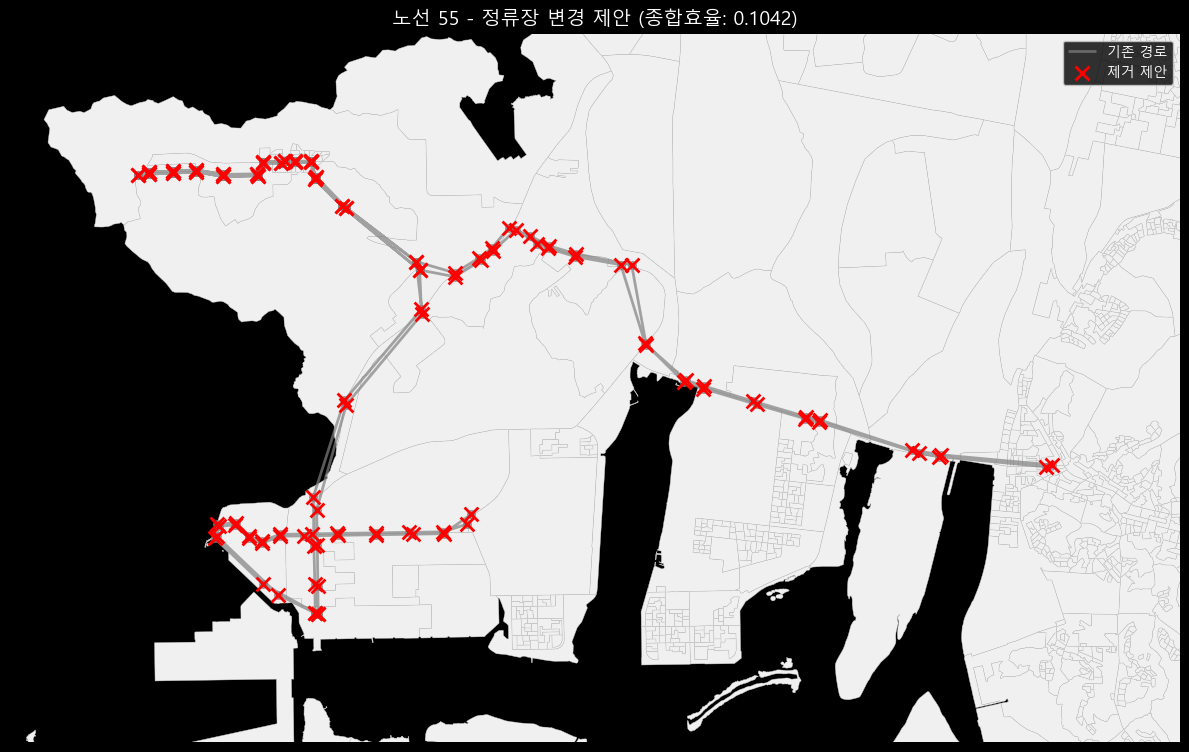

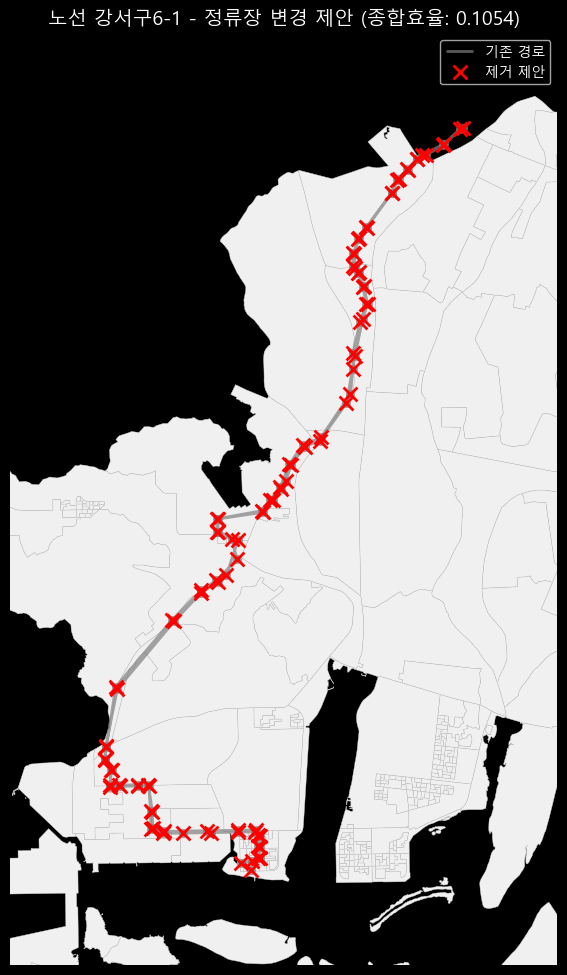

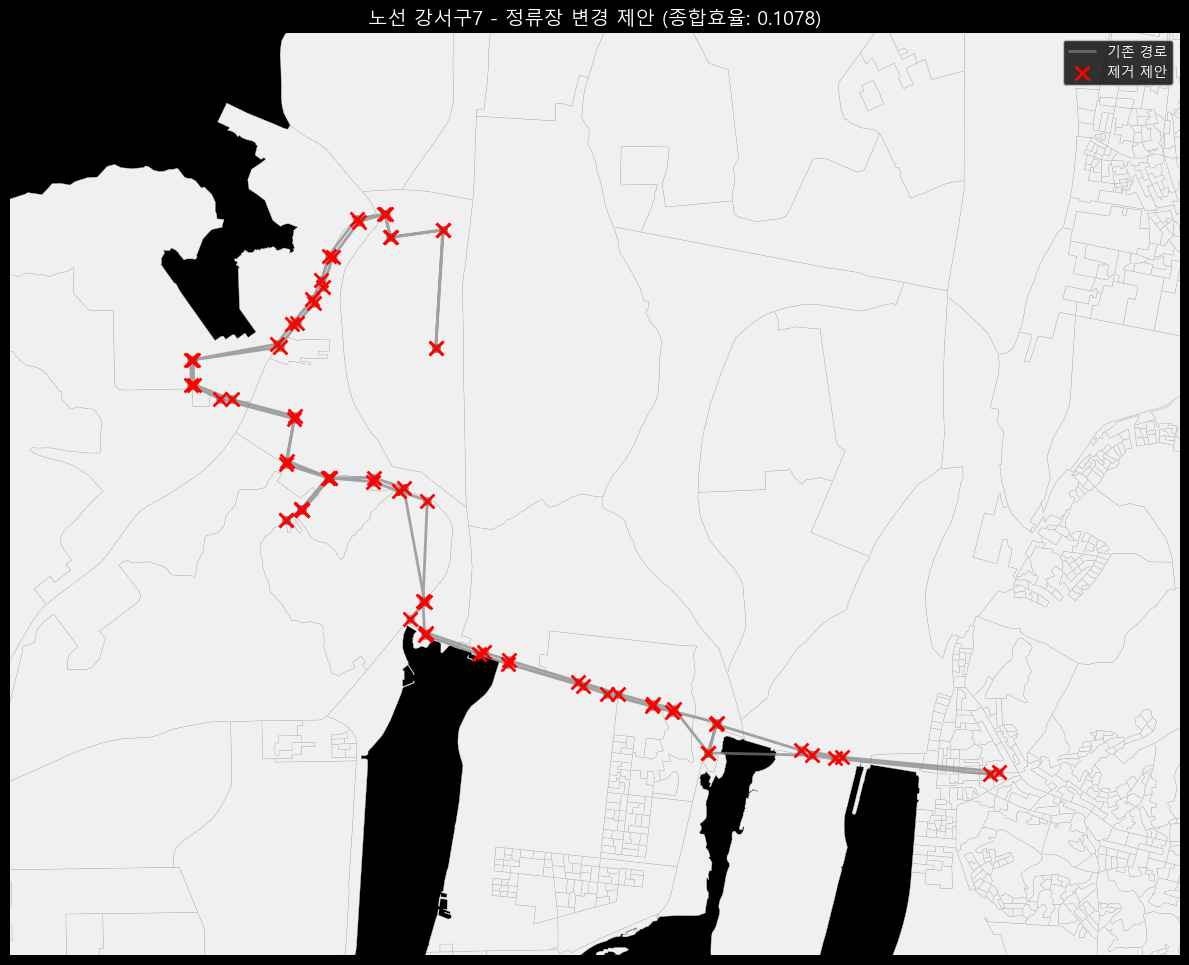

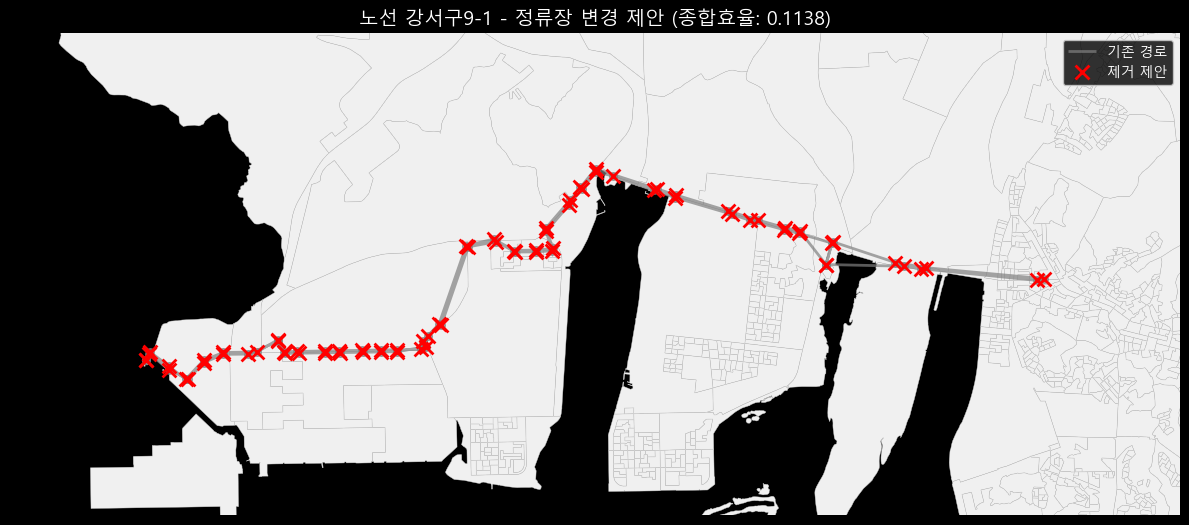

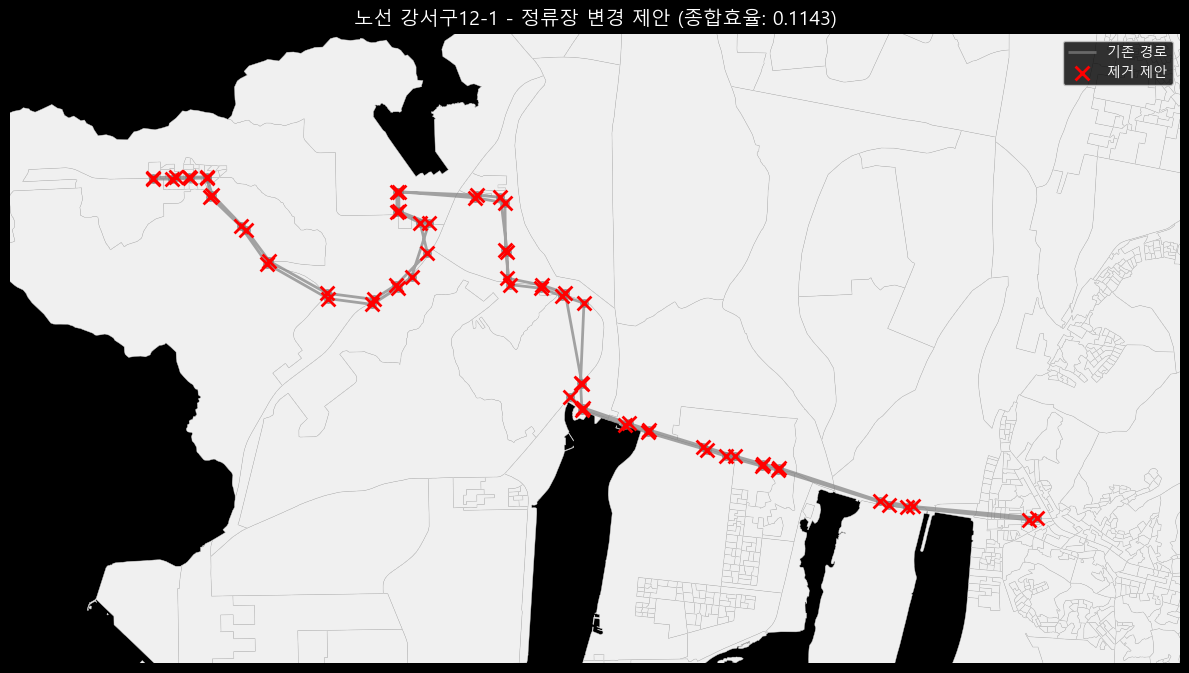

시각화 완료


In [30]:
# ===========================================================
# 시각화: 비효율 노선별 기존 경로 vs 변경 제안 지도
# ===========================================================
print('비효율 노선 시각화 중...')

for _, route_row in inefficient_topk.head(5).iterrows():  # 상위 5개 노선만
    route_id = route_row['노선번호']
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 10))
    
    # 배경: 집계구 경계
    route_stops = bus_routes_gdf[bus_routes_gdf['노선번호'] == route_id]
    bounds = route_stops.total_bounds
    margin = 2000
    ax.set_xlim(bounds[0]-margin, bounds[2]+margin)
    ax.set_ylim(bounds[1]-margin, bounds[3]+margin)
    
    census.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)
    
    # 기존 경로 (회색)
    if route_id in route_lines:
        route_line_gdf = gpd.GeoDataFrame(
            geometry=[route_lines[route_id]], crs=TARGET_CRS
        )
        route_line_gdf.plot(ax=ax, color='gray', linewidth=2, alpha=0.7, label='기존 경로')
    
    # 기존 정류소
    route_stops.plot(ax=ax, color='gray', markersize=30, zorder=5, alpha=0.7)
    
    # 제거 제안 (빨간 X)
    route_proposals = proposals_df[proposals_df['노선번호'] == route_id]
    remove_props = route_proposals[route_proposals['변경유형'] == '제거']
    if len(remove_props) > 0:
        ax.scatter(remove_props['X좌표'], remove_props['Y좌표'],
                   color='red', marker='x', s=100, zorder=10, linewidths=2, label='제거 제안')
    
    # 추가 제안 (파란 별)
    add_props = route_proposals[route_proposals['변경유형'] == '추가']
    if len(add_props) > 0:
        ax.scatter(add_props['X좌표'], add_props['Y좌표'],
                   color='blue', marker='*', s=150, zorder=10, label='추가 제안')
    
    ax.set_title(f'노선 {route_id} - 정류장 변경 제안 (종합효율: {route_row["종합효율점수"]:.4f})', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.savefig(f'{RESULT_DIR}\\fig_route_{route_id}_proposal.png', dpi=150, bbox_inches='tight')
    plt.show()
    
print('시각화 완료')

---
## Part 3. 시나리오 2 - 심야 버스 노선 신설

### 3-1. 심야 수요 분석

In [31]:
# ===========================================================
# 심야(0~5시) 교통카드 이용량 분석
# ===========================================================
print('=== 심야 수요 분석 (0~5시) ===')

night_card = card_df[card_df['심야여부']].copy()
night_bus = night_card[night_card['수단'] == '버스'].copy()
night_subway = night_card[night_card['수단'] == '지하철'].copy()

print(f'심야 전체 거래: {len(night_card):,}건')
print(f'  버스: {len(night_bus):,}건')
print(f'  지하철: {len(night_subway):,}건')

# 기존 심야 버스 노선 존재 여부
night_routes = night_bus[night_bus['transport_name'].astype(str).str.contains('심야', na=False)]
existing_night_routes = night_routes['transport_name'].unique()
print(f'\n기존 심야 버스 노선: {len(existing_night_routes)}개')
for r in existing_night_routes:
    cnt = (night_routes['transport_name'] == r).sum()
    print(f'  {r}: {cnt:,}건')

# 심야 비-심야노선 이용현황
non_night_routes_usage = night_bus[~night_bus['transport_name'].astype(str).str.contains('심야', na=False)]
print(f'\n심야 시간 비-심야노선 이용: {len(non_night_routes_usage):,}건')
print(f'  이용 노선 수: {non_night_routes_usage["transport_name"].nunique()}')

=== 심야 수요 분석 (0~5시) ===
심야 전체 거래: 1,515,213건
  버스: 823,652건
  지하철: 691,561건

기존 심야 버스 노선: 10개
  1001(심야): 4,140건
  182(심야): 50건
  1000(심야): 256건
  141(심야): 5,308건
  183(심야): 1,309건
  1002(심야): 2,828건
  1003(심야): 7,635건
  58-1(심야): 736건
  2(심야): 2,736건
  1004(심야): 2,219건

심야 시간 비-심야노선 이용: 796,435건
  이용 노선 수: 252


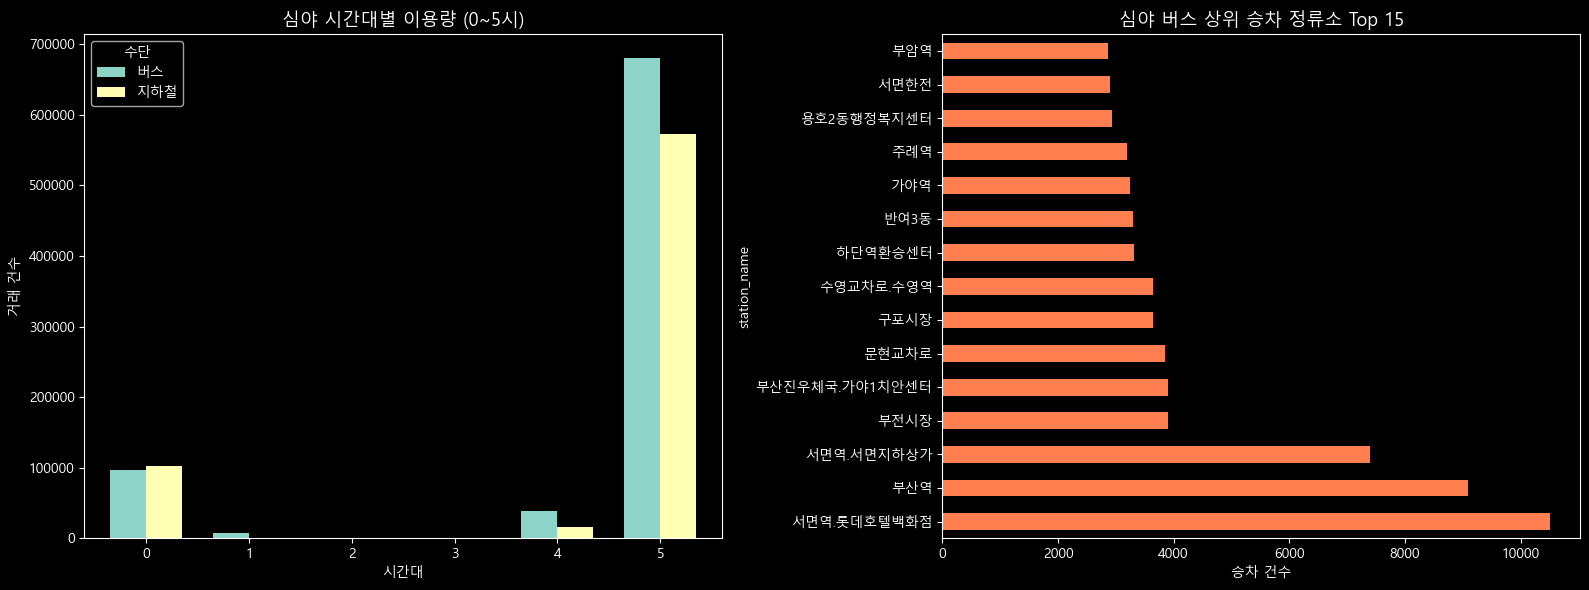

In [32]:
# 심야 시간대별 이용량 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 시간대별 (0~5시 세분화)
night_hourly = night_card.groupby(['시간대', '수단']).size().unstack(fill_value=0)
night_hourly.plot(kind='bar', ax=axes[0], width=0.7)
axes[0].set_title('심야 시간대별 이용량 (0~5시)', fontsize=13)
axes[0].set_xlabel('시간대')
axes[0].set_ylabel('거래 건수')
axes[0].tick_params(axis='x', rotation=0)

# 심야 버스 상위 정류소
night_bus_boarding = night_bus[night_bus['승하차'] == '승차']
top_night_stops = night_bus_boarding.groupby('station_name').size().nlargest(15)
top_night_stops.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('심야 버스 상위 승차 정류소 Top 15', fontsize=13)
axes[1].set_xlabel('승차 건수')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\fig_night_demand.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# 심야 생활인구 + 카드소비 연계 분석
print('=== 심야 생활인구 + 카드소비 연계 ===')

# 심야 카드소비 (시간대 0~5)
night_consume = card_consume_tme[card_consume_tme['tme'].isin([0, 1, 2, 3, 4, 5])]
night_consume_grid = night_consume.groupby('id').agg(
    심야소비금액=('amt', 'sum'),
    심야소비건수=('cnt', 'sum')
).reset_index()

print(f'심야 카드소비 격자 수: {len(night_consume_grid):,}')
print(f'심야 총 소비금액: {night_consume_grid["심야소비금액"].sum():,.0f}원')

# 격자에 심야 데이터 병합 (타입 맞춤)
grid_night_pop['id'] = grid_night_pop['id'].astype(str)  # int64 -> str
night_consume_grid['id'] = night_consume_grid['id'].astype(str)  # int64 -> str

grid_night = grid_50m.merge(grid_night_pop, on='id', how='left')
grid_night = grid_night.merge(night_consume_grid, on='id', how='left')
grid_night['평균심야인구'] = grid_night['평균심야인구'].fillna(0)
grid_night['심야소비금액'] = grid_night['심야소비금액'].fillna(0)

# 심야 수요 종합 점수
grid_night['심야수요점수'] = (
        normalize(grid_night['평균심야인구']) * 0.6 +
        normalize(grid_night['심야소비금액']) * 0.4
)

print(f'심야 수요 점수 통계:')
print(grid_night['심야수요점수'].describe().round(4))


=== 심야 생활인구 + 카드소비 연계 ===
심야 카드소비 격자 수: 13,086
심야 총 소비금액: 57,503,858,685원
심야 수요 점수 통계:
count    310241.0000
mean          0.0048
std           0.0139
min           0.0000
25%           0.0000
50%           0.0002
75%           0.0025
max           0.6224
Name: 심야수요점수, dtype: float64


### 3-2. 심야 서비스 공백 분석

In [35]:
# ===========================================================
# 기존 심야 노선 커버리지 (400m 버퍼)
# ===========================================================
print('=== 심야 서비스 공백 분석 ===')

# 기존 심야 노선 정류소
night_route_stops = bus_routes_gdf[
    bus_routes_gdf['노선번호'].astype(str).str.contains('심야')
]

if len(night_route_stops) > 0:
    night_buffer = unary_union(night_route_stops.geometry.buffer(400))
    print(f'기존 심야 노선 정류소 수: {len(night_route_stops):,}')
    
    # 커버 영역 내/외 격자 분류
    grid_night['심야커버'] = grid_night.geometry.intersects(night_buffer)
else:
    print('기존 심야 노선 정류소 없음 (노선명 매칭 실패 가능)')
    # transport_name 기반으로 재탐색
    night_transport_names = [str(r) for r in existing_night_routes]
    night_route_stops_alt = bus_routes_gdf[
        bus_routes_gdf['노선번호'].isin(night_transport_names)
    ]
    if len(night_route_stops_alt) > 0:
        night_route_stops = night_route_stops_alt
        night_buffer = unary_union(night_route_stops.geometry.buffer(400))
        grid_night['심야커버'] = grid_night.geometry.intersects(night_buffer)
        print(f'대안 매칭: {len(night_route_stops):,}개 정류소')
    else:
        grid_night['심야커버'] = False
        night_buffer = None
        print('심야 노선 정류소 매칭 불가 - 전체를 공백으로 처리')

# 심야 수요 있지만 서비스 안 되는 공백 지역
# 수요 있음 = 심야수요점수 상위 30%
demand_threshold = grid_night['심야수요점수'].quantile(0.70)
grid_night['수요있음'] = grid_night['심야수요점수'] >= demand_threshold
grid_night['공백지역'] = grid_night['수요있음'] & ~grid_night['심야커버']

print(f'\n심야 수요 있는 격자: {grid_night["수요있음"].sum():,}개')
print(f'기존 서비스 커버 격자: {grid_night["심야커버"].sum():,}개')
print(f'공백 지역 (수요 있지만 서비스 없음): {grid_night["공백지역"].sum():,}개')

=== 심야 서비스 공백 분석 ===
기존 심야 노선 정류소 수: 1,749

심야 수요 있는 격자: 93,073개
기존 서비스 커버 격자: 63,714개
공백 지역 (수요 있지만 서비스 없음): 46,920개


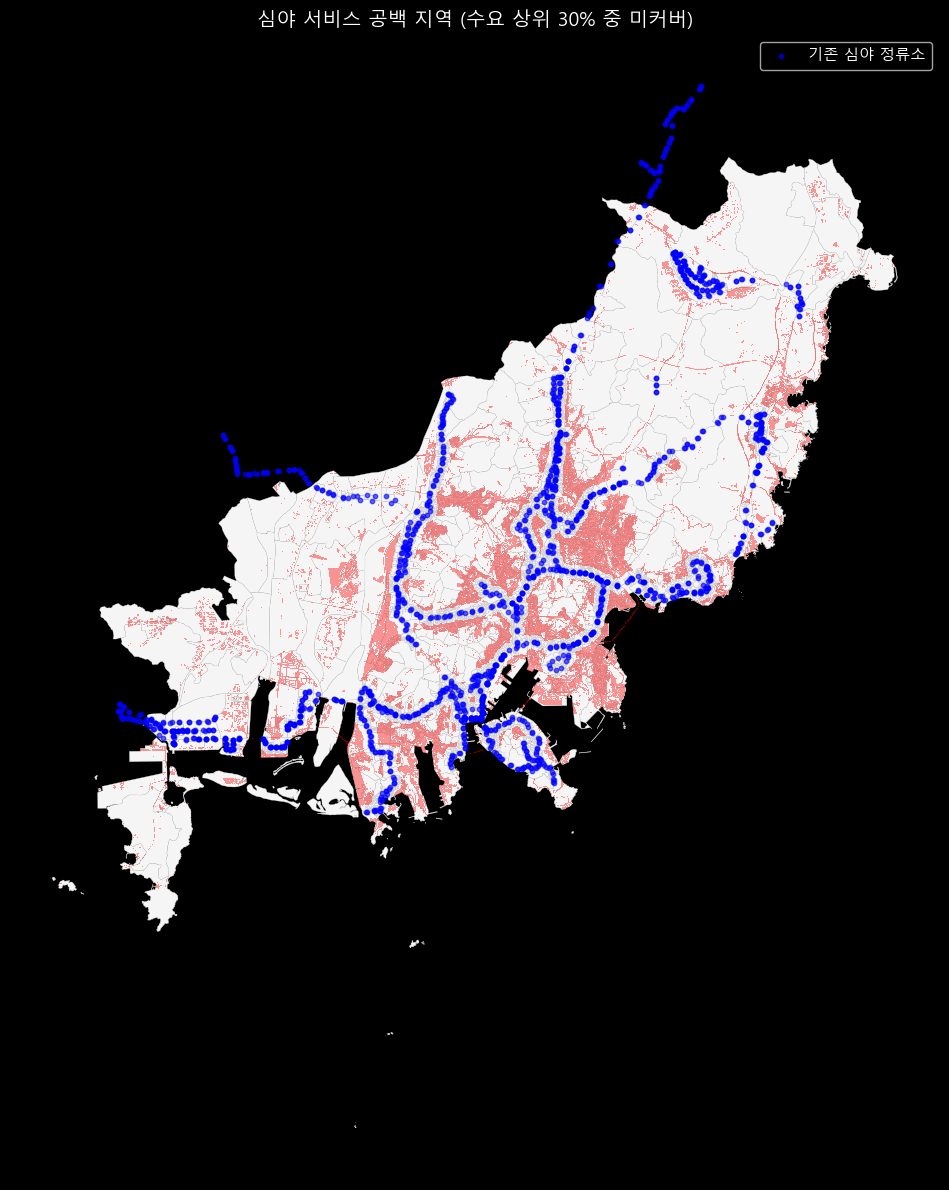

In [36]:
# 공백 지역 시각화
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# 배경
census.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.2)

# 공백 지역 표시
gap_grids = grid_night[grid_night['공백지역']]
if len(gap_grids) > 0:
    gap_grids.plot(ax=ax, color='red', alpha=0.4, label='공백 지역')

# 기존 심야 노선
if len(night_route_stops) > 0:
    night_route_stops.plot(ax=ax, color='blue', markersize=10, alpha=0.6, label='기존 심야 정류소')

ax.set_title('심야 서비스 공백 지역 (수요 상위 30% 중 미커버)', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\fig_night_gap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3-3. 심야 노선 제안

In [37]:
# ===========================================================
# 공백 지역 수요 클러스터링 (DBSCAN)
# ===========================================================
print('=== 심야 공백 지역 클러스터링 (DBSCAN) ===')

# 공백 격자의 중심점 좌표
gap_centroids = gap_grids.copy()
gap_centroids['cx'] = gap_centroids.geometry.centroid.x
gap_centroids['cy'] = gap_centroids.geometry.centroid.y

coords = gap_centroids[['cx', 'cy']].values

# DBSCAN 파라미터: eps=500m, min_samples=10
db = DBSCAN(eps=500, min_samples=10)
gap_centroids['cluster'] = db.fit_predict(coords)

# 노이즈 제거 (cluster == -1)
clusters = gap_centroids[gap_centroids['cluster'] >= 0]
n_clusters = clusters['cluster'].nunique()

print(f'클러스터 수: {n_clusters}')
print(f'노이즈 포인트: {(gap_centroids["cluster"] == -1).sum()}')

# 클러스터별 정보
cluster_info = clusters.groupby('cluster').agg(
    격자수=('id', 'count'),
    평균수요=('심야수요점수', 'mean'),
    중심X=('cx', 'mean'),
    중심Y=('cy', 'mean')
).reset_index()
cluster_info = cluster_info.sort_values('평균수요', ascending=False)

print(f'\n클러스터별 정보:')
print(cluster_info.to_string(index=False))

=== 심야 공백 지역 클러스터링 (DBSCAN) ===
클러스터 수: 52
노이즈 포인트: 276

클러스터별 정보:
 cluster  격자수     평균수요          중심X          중심Y
       6 5974 0.019348 1.148068e+06 1.689199e+06
      51  231 0.019294 1.150936e+06 1.693582e+06
      42  314 0.018755 1.143269e+06 1.690131e+06
      33 7129 0.017769 1.139827e+06 1.689990e+06
      32  278 0.017505 1.135260e+06 1.680373e+06
      37   32 0.014827 1.139459e+06 1.680252e+06
       0 7398 0.014153 1.145422e+06 1.683091e+06
      44   28 0.013331 1.143441e+06 1.698011e+06
      34 2008 0.012693 1.139410e+06 1.683838e+06
      16   22 0.011583 1.163482e+06 1.705673e+06
      46 2504 0.011435 1.145914e+06 1.693982e+06
      39  215 0.010510 1.141799e+06 1.678167e+06
      31 3434 0.010368 1.136277e+06 1.677199e+06
      45  213 0.009668 1.144229e+06 1.677145e+06
      25  125 0.008867 1.127823e+06 1.676995e+06
       2 1588 0.008558 1.132500e+06 1.676791e+06
      11  200 0.006591 1.155404e+06 1.694970e+06
       3 5681 0.006280 1.132300e+06 1.684883e+06
  

In [38]:
# ===========================================================
# 심야 노선 설계 (노드-링크 기반)
# ===========================================================
print('=== 심야 노선 설계 ===')

# 상위 수요 클러스터 연결 (TSP-like 순서)
# 클러스터 수가 충분하면 상위 N개 연결
N_CLUSTERS_TO_CONNECT = min(n_clusters, 8)  # 최대 8개 클러스터 연결
top_clusters = cluster_info.head(N_CLUSTERS_TO_CONNECT)

# 클러스터 중심에서 가장 가까운 기존 정류소 찾기
stop_tree = cKDTree(
    np.column_stack([bus_stops_shp.geometry.x.values, bus_stops_shp.geometry.y.values])
)

cluster_stops = []
for _, cluster in top_clusters.iterrows():
    _, idx = stop_tree.query([cluster['중심X'], cluster['중심Y']])
    stop = bus_stops_shp.iloc[idx]
    cluster_stops.append({
        'cluster': cluster['cluster'],
        'bstopid': stop['bstopid'],
        'bstopnm': stop['bstopnm'],
        'x': stop.geometry.x,
        'y': stop.geometry.y,
        '평균수요': cluster['평균수요']
    })

cluster_stops_df = pd.DataFrame(cluster_stops)
print(f'연결 대상 클러스터 수: {len(cluster_stops_df)}')
print(cluster_stops_df[['cluster','bstopnm','평균수요']].to_string(index=False))

# 노선 순서 결정 (Nearest Neighbor 휴리스틱)
def nearest_neighbor_order(points):
    """Nearest Neighbor TSP 휴리스틱으로 방문 순서 결정"""
    n = len(points)
    visited = [False] * n
    order = [0]  # 첫 번째 점에서 시작
    visited[0] = True
    
    for _ in range(n - 1):
        curr = order[-1]
        best_dist = float('inf')
        best_next = -1
        for j in range(n):
            if not visited[j]:
                d = np.sqrt((points[curr][0]-points[j][0])**2 + (points[curr][1]-points[j][1])**2)
                if d < best_dist:
                    best_dist = d
                    best_next = j
        if best_next >= 0:
            order.append(best_next)
            visited[best_next] = True
    
    return order

cluster_coords = cluster_stops_df[['x','y']].values.tolist()
visit_order = nearest_neighbor_order(cluster_coords)
ordered_stops = cluster_stops_df.iloc[visit_order].reset_index(drop=True)

print(f'\n노선 방문 순서:')
for i, (_, stop) in enumerate(ordered_stops.iterrows()):
    print(f'  {i+1}. {stop["bstopnm"]} (클러스터 {stop["cluster"]})')

=== 심야 노선 설계 ===
연결 대상 클러스터 수: 8
 cluster     bstopnm     평균수요
     6.0      재송시장입구 0.019348
    51.0       삼한아파트 0.019294
    42.0   부산교육대학교후문 0.018755
    33.0      만덕고등학교 0.017769
    32.0 동원베네스트1차아파트 0.017505
    37.0      부산디지털고 0.014827
     0.0      유엔조각공원 0.014153
    44.0 부산외국어대학교캠퍼스 0.013331

노선 방문 순서:
  1. 재송시장입구 (클러스터 6.0)
  2. 부산교육대학교후문 (클러스터 42.0)
  3. 만덕고등학교 (클러스터 33.0)
  4. 부산외국어대학교캠퍼스 (클러스터 44.0)
  5. 삼한아파트 (클러스터 51.0)
  6. 유엔조각공원 (클러스터 0.0)
  7. 부산디지털고 (클러스터 37.0)
  8. 동원베네스트1차아파트 (클러스터 32.0)


In [39]:
# 노드-링크 기반 실제 도로 경로로 노선 설계
print('노드-링크 기반 경로 설계 중...')

proposed_route_nodes = []
proposed_route_length = 0
proposed_waypoints = []  # 경유 정류소

for i in range(len(ordered_stops) - 1):
    src = ordered_stops.iloc[i]
    dst = ordered_stops.iloc[i+1]
    
    # 최단 경로
    path = shortest_path_nodes(src['x'], src['y'], dst['x'], dst['y'])
    seg_len = shortest_path_length(src['x'], src['y'], dst['x'], dst['y'])
    
    if path:
        proposed_route_nodes.extend(path if i == 0 else path[1:])  # 중복 노드 제거
    if pd.notna(seg_len):
        proposed_route_length += seg_len
    
    # 경로 중간에 기존 정류소 추가 (경로 상 1km 간격)
    if path and len(path) > 2:
        # 경로 상의 노드 좌표
        path_coords = [(G_car.nodes[n].get('x',0), G_car.nodes[n].get('y',0)) for n in path]
        cum_dist = 0
        last_stop_dist = 0
        
        for j in range(1, len(path_coords)):
            dx = path_coords[j][0] - path_coords[j-1][0]
            dy = path_coords[j][1] - path_coords[j-1][1]
            seg = np.sqrt(dx**2 + dy**2)
            cum_dist += seg
            
            if cum_dist - last_stop_dist >= 1000:  # 1km 간격
                # 가장 가까운 기존 정류소 찾기
                _, stop_idx = stop_tree.query(path_coords[j])
                nearest_stop = bus_stops_shp.iloc[stop_idx]
                # 경로에서 500m 이내인 경우만
                stop_dist = np.sqrt(
                    (nearest_stop.geometry.x - path_coords[j][0])**2 +
                    (nearest_stop.geometry.y - path_coords[j][1])**2
                )
                if stop_dist <= 500:
                    proposed_waypoints.append({
                        'bstopid': nearest_stop['bstopid'],
                        'bstopnm': nearest_stop['bstopnm'],
                        'x': nearest_stop.geometry.x,
                        'y': nearest_stop.geometry.y
                    })
                    last_stop_dist = cum_dist

# 중복 정류소 제거
waypoints_df = pd.DataFrame(proposed_waypoints).drop_duplicates(subset='bstopid')

# 경유 정류소에 주요 클러스터 정류소 추가
full_stops = pd.concat([
    ordered_stops[['bstopid','bstopnm','x','y']],
    waypoints_df
]).drop_duplicates(subset='bstopid').reset_index(drop=True)

print(f'\n=== 제안 심야 노선 ===')
print(f'총 경로 길이: {proposed_route_length/1000:.2f} km')
print(f'주요 정류소 (클러스터 중심): {len(ordered_stops)}개')
print(f'경유 정류소 (1km 간격): {len(waypoints_df)}개')
print(f'전체 경유 정류소: {len(full_stops)}개')

print(f'\n경유 정류소 목록:')
print(full_stops[['bstopid','bstopnm']].to_string(index=False))

노드-링크 기반 경로 설계 중...

=== 제안 심야 노선 ===
총 경로 길이: 1.06 km
주요 정류소 (클러스터 중심): 8개
경유 정류소 (1km 간격): 32개
전체 경유 정류소: 38개

경유 정류소 목록:
  bstopid     bstopnm
184730102      재송시장입구
193720102   부산교육대학교후문
182940201      만덕고등학교
217510101 부산외국어대학교캠퍼스
184580201       삼한아파트
502500000      유엔조각공원
167840204      부산디지털고
179090101 동원베네스트1차아파트
504690000         평전교
209380301     고원3차아파트
167640101        OK슈퍼
502510000      유엔조각공원
201040201         화광빌
182960101      만덕고등학교
197270201          석길
212760402      정관산단입구
174890303   남산동.요산문학관
510250000      동해선좌천역
500760000          하근
196250102      농업기술센터
196700104          칠암
184570102       남흥아파트
216990101       대양중공업
500540000         원적사
197470102      월내초등학교
196690104          칠암
197480302        월내농협
500160000       LH4단지
196690101          신평
500650000      장안초등학교
165920402  동부산아이존빌아파트
167830101      부산디지털고
173640301         회동동
215840101        가동마을
500230000          기룡
500600000      이지더원5차
180750303       경성대학교
213690101       우림아파트


In [40]:
# 기존 노선 중복도 검증
print('=== 기존 노선 중복도 검증 ===')

# 제안 노선 경유 정류소가 기존 심야 노선에 포함되는 비율
proposed_stop_ids = set(full_stops['bstopid'].astype(str))

night_existing_stop_ids = set(
    night_route_stops['정류소ID'].astype(str)
) if len(night_route_stops) > 0 else set()

overlap_count = len(proposed_stop_ids & night_existing_stop_ids)
overlap_rate = overlap_count / len(proposed_stop_ids) if len(proposed_stop_ids) > 0 else 0

print(f'제안 정류소 수: {len(proposed_stop_ids)}')
print(f'기존 심야 노선 정류소 수: {len(night_existing_stop_ids)}')
print(f'중복 정류소: {overlap_count}개 ({overlap_rate*100:.1f}%)')

if overlap_rate < 0.3:
    print('=> 기존 심야 노선과 중복도 낮음 - 신규 노선으로 적합')
else:
    print('=> 기존 심야 노선과 중복도 높음 - 경로 조정 필요')

=== 기존 노선 중복도 검증 ===
제안 정류소 수: 38
기존 심야 노선 정류소 수: 1374
중복 정류소: 0개 (0.0%)
=> 기존 심야 노선과 중복도 낮음 - 신규 노선으로 적합


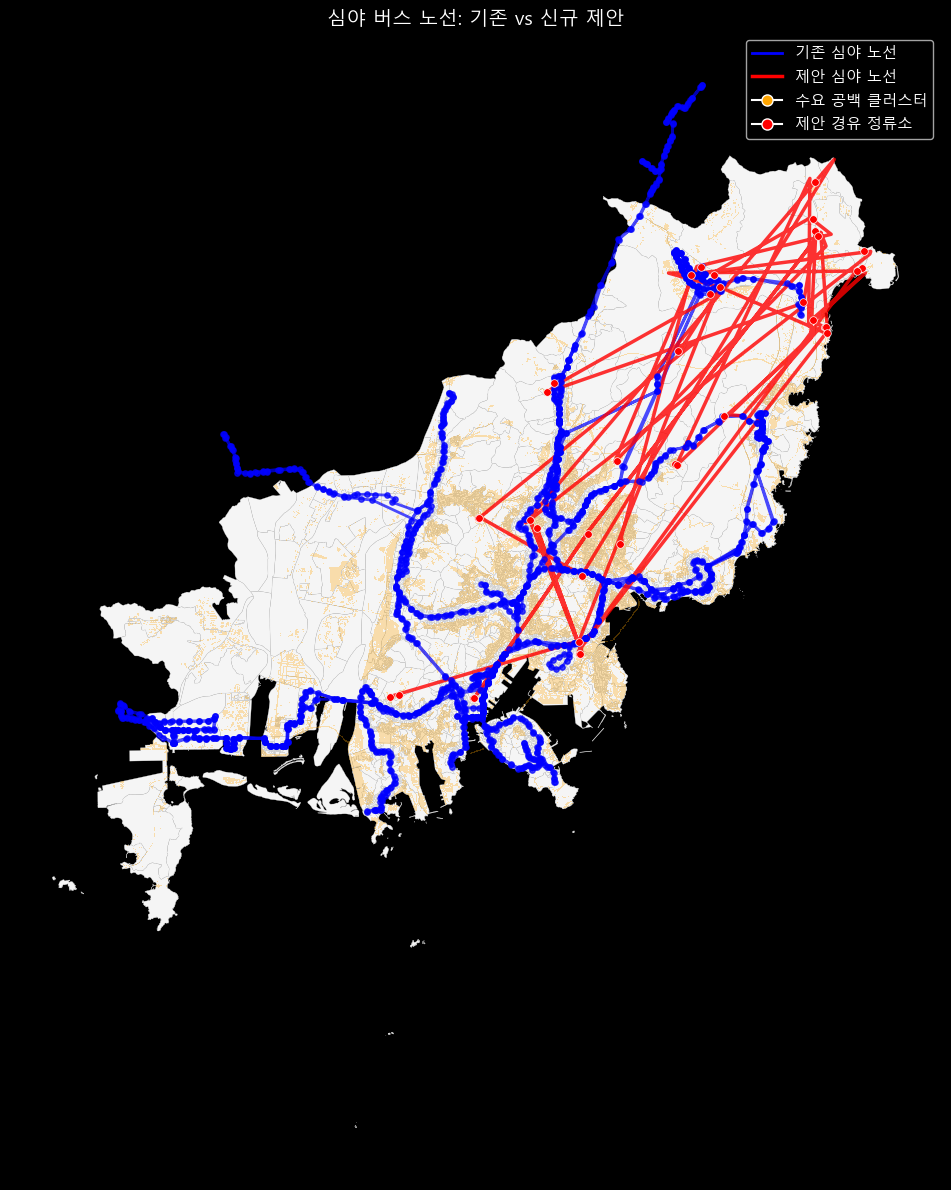

In [41]:
# ===========================================================
# 심야 노선 시각화: 기존(파랑) + 신규 제안(빨강)
# ===========================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# 배경
census.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.2)

# 클러스터 표시
for cl_id in clusters['cluster'].unique():
    cl_data = clusters[clusters['cluster'] == cl_id]
    cl_data.plot(ax=ax, color='orange', alpha=0.3, markersize=2)

# 기존 심야 노선 (파랑)
if len(night_route_stops) > 0:
    # 기존 심야 노선 LineString
    for route_id in night_route_stops['노선번호'].unique():
        rg = night_route_stops[night_route_stops['노선번호']==route_id].sort_values('정류소순번')
        if len(rg) >= 2:
            coords = list(rg.geometry.apply(lambda g: (g.x, g.y)))
            line = LineString(coords)
            gpd.GeoDataFrame(geometry=[line], crs=TARGET_CRS).plot(
                ax=ax, color='blue', linewidth=2, alpha=0.7
            )
    night_route_stops.plot(ax=ax, color='blue', markersize=15, zorder=5, alpha=0.7)

# 제안 노선 (빨강)
if proposed_route_nodes:
    proposed_coords = [(G_car.nodes[n].get('x',0), G_car.nodes[n].get('y',0)) for n in proposed_route_nodes]
    if len(proposed_coords) >= 2:
        proposed_line = LineString(proposed_coords)
        gpd.GeoDataFrame(geometry=[proposed_line], crs=TARGET_CRS).plot(
            ax=ax, color='red', linewidth=2.5, alpha=0.8
        )

# 제안 정류소
full_stops_gdf = gpd.GeoDataFrame(
    full_stops, geometry=gpd.points_from_xy(full_stops['x'], full_stops['y']), crs=TARGET_CRS
)
full_stops_gdf.plot(ax=ax, color='red', markersize=30, zorder=10, edgecolor='white', linewidth=0.5)

# 범례
legend_elements = [
    Line2D([0], [0], color='blue', linewidth=2, label='기존 심야 노선'),
    Line2D([0], [0], color='red', linewidth=2.5, label='제안 심야 노선'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='수요 공백 클러스터'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8, label='제안 경유 정류소'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=11)
ax.set_title('심야 버스 노선: 기존 vs 신규 제안', fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}\\fig_night_route_proposal.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4. 종합 결과 저장

In [42]:
# ===========================================================
# 결과 CSV 저장
# ===========================================================
print('=== 결과 저장 ===')

# 1) 노선별 효율성 점수
save_cols = ['노선번호', '노선유형', '정류소수', '노선길이_km', '일평균승차량',
             '수요효율', '커버리지효율', '중복도', 'CV', '첨두비율',
             '사회형평점수', '경제활동밀도', '종합효율점수', '효율순위']
efficiency[save_cols].to_csv(
    f'{RESULT_DIR}\\노선별_효율성점수.csv', index=False, encoding='utf-8-sig'
)
print(f'1) 노선별_효율성점수.csv 저장 완료 ({len(efficiency)}건)')

# 2) 비효율 노선 Top-K
inefficient_topk[save_cols].to_csv(
    f'{RESULT_DIR}\\비효율노선_Top{K}.csv', index=False, encoding='utf-8-sig'
)
print(f'2) 비효율노선_Top{K}.csv 저장 완료 ({len(inefficient_topk)}건)')

# 3) 정류장 변경 제안
proposals_df.to_csv(
    f'{RESULT_DIR}\\정류장_변경제안.csv', index=False, encoding='utf-8-sig'
)
print(f'3) 정류장_변경제안.csv 저장 완료 ({len(proposals_df)}건)')

# 4) 하차 추정 결과 통계
estimation_stats = trip_pairs_estimated['추정방법'].value_counts().reset_index()
estimation_stats.columns = ['추정방법', '건수']
estimation_stats.to_csv(
    f'{RESULT_DIR}\\하차추정_통계.csv', index=False, encoding='utf-8-sig'
)
print(f'4) 하차추정_통계.csv 저장 완료')

# 5) 심야 노선 제안 경유 정류소
full_stops.to_csv(
    f'{RESULT_DIR}\\심야노선_제안_정류소.csv', index=False, encoding='utf-8-sig'
)
print(f'5) 심야노선_제안_정류소.csv 저장 완료 ({len(full_stops)}건)')

# 6) 심야 공백 클러스터 정보
cluster_info.to_csv(
    f'{RESULT_DIR}\\심야_공백_클러스터.csv', index=False, encoding='utf-8-sig'
)
print(f'6) 심야_공백_클러스터.csv 저장 완료 ({len(cluster_info)}건)')

print(f'\n모든 결과가 {RESULT_DIR} 에 저장되었습니다.')

# 저장된 파일 목록
print(f'\n=== 저장 파일 목록 ===')
for f in os.listdir(RESULT_DIR):
    fpath = os.path.join(RESULT_DIR, f)
    size = os.path.getsize(fpath)
    print(f'  {f} ({size/1024:.1f} KB)')

=== 결과 저장 ===
1) 노선별_효율성점수.csv 저장 완료 (326건)
2) 비효율노선_Top10.csv 저장 완료 (10건)
3) 정류장_변경제안.csv 저장 완료 (817건)
4) 하차추정_통계.csv 저장 완료
5) 심야노선_제안_정류소.csv 저장 완료 (38건)
6) 심야_공백_클러스터.csv 저장 완료 (52건)

모든 결과가 C:\Users\HP\Desktop\작업 폴더\01.work\리버풀\데이터\results_optimization 에 저장되었습니다.

=== 저장 파일 목록 ===
  fig_night_demand.png (78.4 KB)
  fig_night_gap.png (496.0 KB)
  fig_night_route_proposal.png (574.9 KB)
  fig_route_55_proposal.png (312.5 KB)
  fig_route_강서구12-1_proposal.png (259.5 KB)
  fig_route_강서구6-1_proposal.png (178.8 KB)
  fig_route_강서구7_proposal.png (332.0 KB)
  fig_route_강서구9-1_proposal.png (227.8 KB)
  노선별_효율성점수.csv (55.1 KB)
  비효율노선_Top10.csv (1.9 KB)
  심야_공백_클러스터.csv (3.3 KB)
  심야노선_제안_정류소.csv (2.4 KB)
  정류장_변경제안.csv (107.7 KB)
  하차추정_통계.csv (0.1 KB)
